# **Fase 3.1 — Agrupamento de Dados: Análise das Notas do ENEM**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [55]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix

### **Realizando a leitura da base de área de MG**

In [24]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Filtrando a área de abrangencia do IFNMG**

In [25]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [26]:
df_scaler = df_ifnmg.copy()

colunas_para_escalar = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])

df_scaler

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

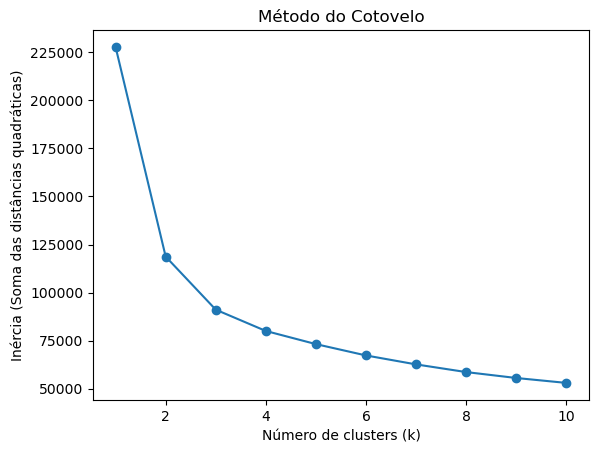

In [27]:
df_notas = df_ifnmg.copy()
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

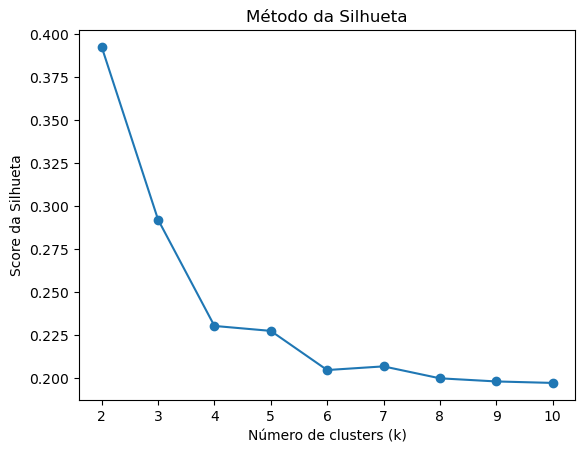

In [28]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Avaliação Interna do Agrupamento e Silhueta para todos os clusters**

Para avaliar a qualidade dos agrupamentos obtidos, foram utilizadas duas métricas internas:
(a) a Soma das Distâncias Quadradas aos Centróides (SSQ), que mede a compacidade dos clusters, e
(b) a Razão entre Distância Intracluster e Intercluster (Intra/Inter), que avalia simultaneamente a coesão interna e a separação entre grupos.

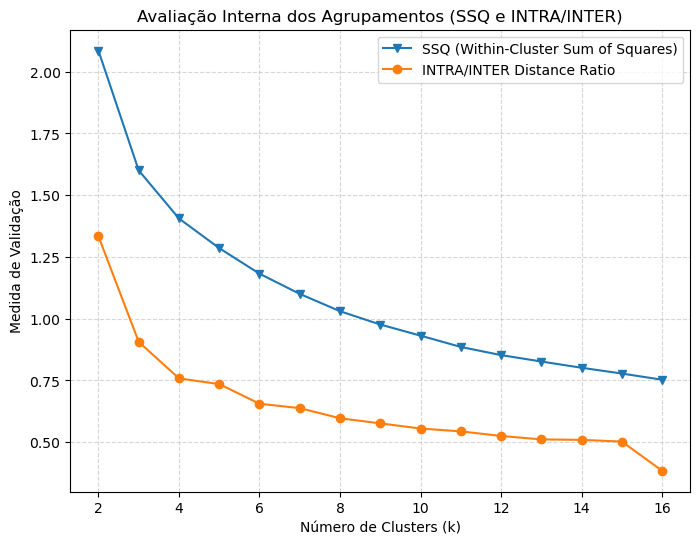

Silhueta global (k=4): 0.2303

Silhueta por cluster:
                      N     media   mediana    desvio    minimo    maximo
Cluster                                                                  
Baixo             13812  0.244700  0.259801  0.132680 -0.023598  0.461842
Levemente Abaixo  19010  0.188134  0.186074  0.104818 -0.008674  0.427269
Acima da Média    15911  0.202795  0.206554  0.116898 -0.069272  0.453045
Muito Alto         8213  0.357164  0.402056  0.147521  0.007729  0.560022


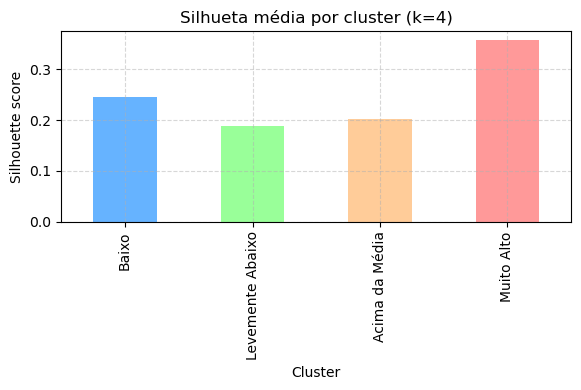

In [29]:
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# Normaliza apenas as notas originais
scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=colunas_notas)

# ============================================================
# 2️⃣ Avaliação Interna (SSQ e INTRA/INTER)
# ============================================================
K = range(2, 17)
ssq_values = []
intra_inter_values = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_norm)
    
    ssq = kmeans.inertia_ / len(df_norm)
    ssq_values.append(ssq)
    
    intra_dists = []
    for label in np.unique(labels):
        cluster_points = df_norm[labels == label]
        if len(cluster_points) > 2:
            sample = cluster_points.sample(n=min(500, len(cluster_points)), random_state=42)
            intra = np.mean(pairwise_distances(sample))
        else:
            intra = 0
        intra_dists.append(intra)
    intra_mean = np.mean(intra_dists)
    
    centers = kmeans.cluster_centers_
    inter_mean = np.mean(pairwise_distances(centers))
    
    intra_inter_ratio = intra_mean / inter_mean
    intra_inter_values.append(intra_inter_ratio)

plt.figure(figsize=(8, 6))
plt.plot(K, ssq_values, 'v-', label='SSQ (Within-Cluster Sum of Squares)')
plt.plot(K, intra_inter_values, 'o-', label='INTRA/INTER Distance Ratio')
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Medida de Validação")
plt.title("Avaliação Interna dos Agrupamentos (SSQ e INTRA/INTER)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ============================================================
# 3️⃣ Modelo Final (k escolhido)
# ============================================================
k_final = 4  # ajuste conforme o resultado do cotovelo
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(df_norm)

# ============================================================
# 4️⃣ Análise de Silhueta
# ============================================================
sil_global = silhouette_score(df_norm, labels)
sil_samples = silhouette_samples(df_norm, labels)

centers = kmeans_final.cluster_centers_
order = centers.mean(axis=1).argsort()                
old2rank = {old:i for i, old in enumerate(order)}     
rank2name = {0:"Baixo", 1:"Levemente Abaixo", 2:"Acima da Média", 3:"Muito Alto"}

df_sil = pd.DataFrame({
    "cluster_id": labels,
    "sil": sil_samples,
})
df_sil["rank"] = df_sil["cluster_id"].map(old2rank)
df_sil["Cluster"] = df_sil["rank"].map(rank2name)

resumo = (
    df_sil
      .groupby(["rank","Cluster"])["sil"]
      .agg(N="count", media="mean", mediana="median", desvio="std", minimo="min", maximo="max")
      .reset_index()
      .sort_values("rank")
      .drop(columns="rank")
      .set_index("Cluster")
)
print(f"Silhueta global (k={k_final}): {sil_global:.4f}\n")
print("Silhueta por cluster:")
print(resumo)

plt.figure(figsize=(6,4))
(
    df_sil.groupby("Cluster")["sil"]
    .mean()
    .reindex(["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"])
    .plot(kind="bar", color=["#66b3ff", "#99ff99", "#ffcc99", "#ff9999"])
)
plt.title(f"Silhueta média por cluster (k={k_final})")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## **Bisecting K-Means**

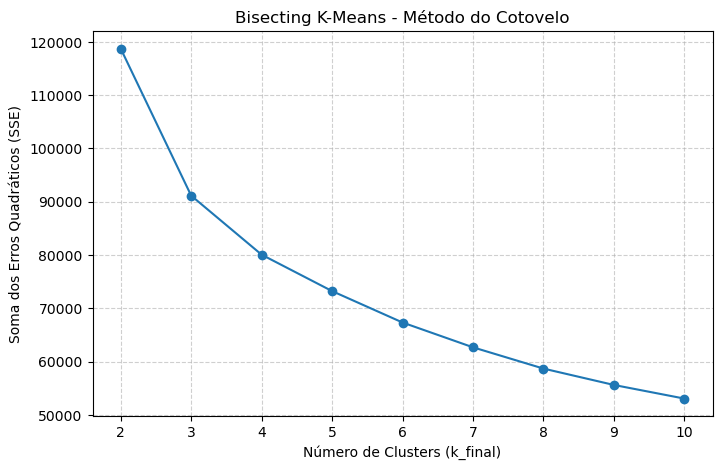

In [56]:
df_notas = df_ifnmg.copy()
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

notas = df_notas[colunas_notas].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(notas)

def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)
    
    while len(clusters) < k_final:
        inertias = {i: KMeans(n_clusters=1, random_state=random_state).fit(X_cluster).inertia_
                    for i, X_cluster in clusters.items()}
        cluster_to_split = max(inertias, key=inertias.get)
        
        X_split = clusters[cluster_to_split]
        kmeans = KMeans(n_clusters=2, n_init=n_init, random_state=random_state)
        split_labels = kmeans.fit_predict(X_split)
        
        new_index = max(clusters.keys()) + 1
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_index] = X_split[split_labels == 1]
        
        mask = labels == cluster_to_split
        labels[mask] = np.where(split_labels == 0, cluster_to_split, new_index)
        
    return labels

resultados = []
intervalo_k = range(2, 11)  # testa de 2 a 10 clusters

for k in intervalo_k:
    labels = bisecting_kmeans(X, k_final=k)
    kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_final.fit(X)
    sse = kmeans_final.inertia_
    resultados.append(sse)

plt.figure(figsize=(8, 5))
plt.plot(intervalo_k, resultados, marker='o')
plt.title("Bisecting K-Means - Método do Cotovelo")
plt.xlabel("Número de Clusters (k_final)")
plt.ylabel("Soma dos Erros Quadráticos (SSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## **Matriz de Confusão**

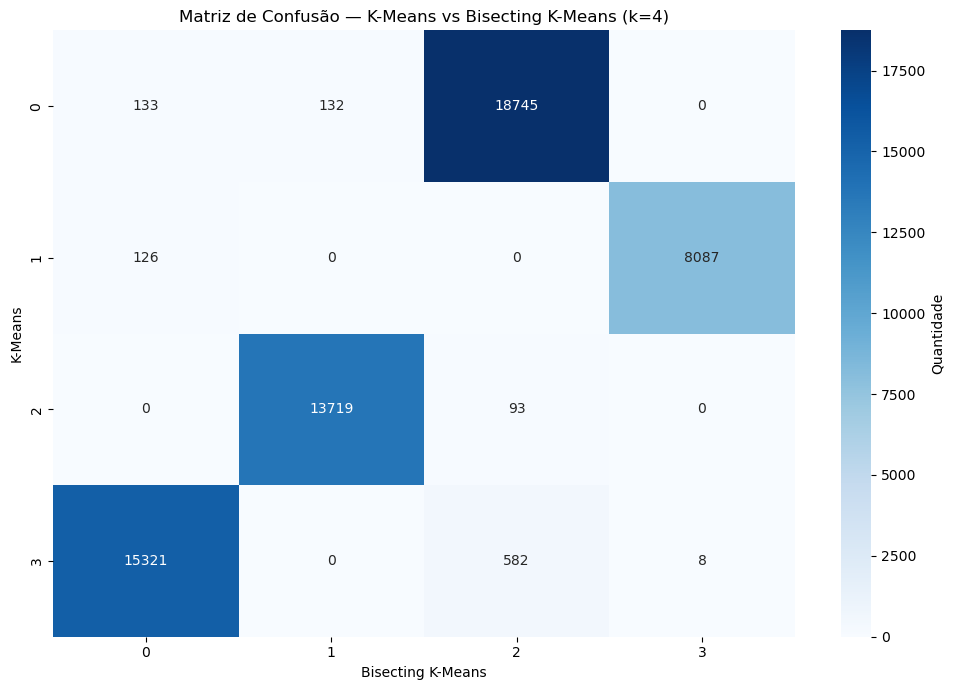

In [57]:
df_notas = df_ifnmg.copy()
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

notas = df_notas[colunas_notas].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(notas)

def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)
    
    while len(clusters) < k_final:
        inertias = {
            i: KMeans(n_clusters=1, random_state=random_state).fit(X_cluster).inertia_
            for i, X_cluster in clusters.items()
        }
        
        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]
        
        kmeans = KMeans(n_clusters=2, n_init=n_init, random_state=random_state)
        split_labels = kmeans.fit_predict(X_split)
        
        new_index = max(clusters.keys()) + 1
        
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_index] = X_split[split_labels == 1]
        
        mask = labels == cluster_to_split
        labels[mask] = np.where(split_labels == 0, cluster_to_split, new_index)
        
    return labels


k_escolhido = 4  

labels_bisect = bisecting_kmeans(X, k_final=k_escolhido)

kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X)

# ================================================================
# Matriz de Confusão entre K-Means e Bisecting K-Means
# ================================================================
cm = confusion_matrix(labels_kmeans, labels_bisect)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar_kws={'label': 'Quantidade'})
plt.xlabel("Bisecting K-Means")
plt.ylabel("K-Means")
plt.title(f"Matriz de Confusão — K-Means vs Bisecting K-Means (k={k_escolhido})")
plt.tight_layout()
plt.show()

## **Análise dos Clusters**

Médias e desvios por cluster (padronizadas):
        NU_NOTA_CN       NU_NOTA_CH       NU_NOTA_LC       NU_NOTA_MT      
              mean   std       mean   std       mean   std       mean   std
Cluster                                                                    
0            -0.41  0.60      -0.19  0.59      -0.14  0.53      -0.43  0.60
1             1.52  0.60       1.32  0.51       1.29  0.54       1.57  0.61
2            -0.86  0.64      -1.15  0.64      -1.20  0.68      -0.82  0.58
3             0.45  0.60       0.54  0.54       0.54  0.53       0.41  0.64


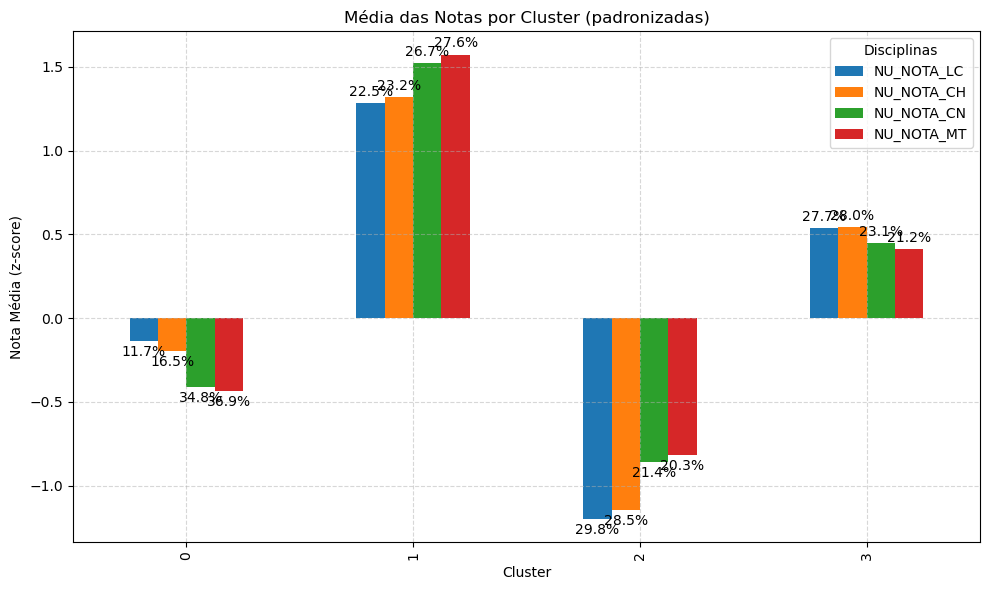

In [31]:
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# ===============================
# 1️⃣ Normalização das notas
# ===============================
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    index=notas.index,
    columns=colunas_notas
)

# ===============================
# 2️⃣ K-Means e agrupamento
# ===============================
k = 4  # escolha com base no gráfico do cotovelo
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(df_norm)

df_norm["Cluster"] = labels_final

# ===============================
# 3️⃣ Resumo estatístico dos clusters
# ===============================
resumo_clusters = (
    df_norm.groupby("Cluster")[colunas_notas]
    .agg(["mean", "std"])
    .round(2)
)
print("Médias e desvios por cluster (padronizadas):")
print(resumo_clusters)

# ===============================
# 4️⃣ Gráfico ordenado pelas médias das disciplinas
# ===============================
resumo_mean = df_norm.groupby("Cluster")[colunas_notas].mean()

# Ordena colunas (disciplinas) do menor para o maior valor médio
ordem_cols = resumo_mean.mean(axis=0).sort_values(ascending=True).index
resumo_sorted = resumo_mean[ordem_cols]

# 👉 Calcula a porcentagem de cada disciplina dentro de cada cluster
# (cada linha = 1 cluster; a soma das 4 disciplinas ≈ 100%)
percent_df = resumo_sorted.div(resumo_sorted.sum(axis=1), axis=0) * 100

# Gráfico com os valores padronizados (z-score)
ax = resumo_sorted.plot(kind="bar", figsize=(10, 6))
plt.title("Média das Notas por Cluster (padronizadas)")
plt.xlabel("Cluster")
plt.ylabel("Nota Média (z-score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Disciplinas")

# 🔹 Colocando as porcentagens (1 casa decimal) sobre cada barrinha
for i, container in enumerate(ax.containers):
    col = resumo_sorted.columns[i]  # disciplina correspondente
    labels = [f"{percent_df.loc[cluster, col]:.1f}%" 
              for cluster in resumo_sorted.index]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

O gráfico apresenta a média padronizada (z-score) das notas por cluster, nas quatro disciplinas avaliadas (Linguagens, Ciências Humanas, Ciências da Natureza e Matemática).

Cluster 0: corresponde ao grupo com pior desempenho, com médias abaixo da média em todas as disciplinas. É um grupo que demandaria maior atenção em ações de reforço e acompanhamento.

Cluster 1: reúne os estudantes com melhor desempenho geral. Eles apresentam médias bem acima da média do conjunto em todas as disciplinas, com destaque para Matemática e Ciências da Natureza, que possuem os maiores z-scores.

Cluster 2: representa alunos um pouco abaixo da média, especialmente em Ciências da Natureza e Matemática, indicando possíveis dificuldades nessas áreas específicas.

Cluster 3: agrupa estudantes com desempenho ligeiramente acima da média, em todas as disciplinas. Não são os melhores, mas formam um grupo relativamente estável e consistente.

De forma geral, o resultado dos clusters permite identificar perfis distintos de desempenho, auxiliando na definição de estratégias direcionadas de intervenção pedagógica para cada grupo.

## **Análise dos clusters com as notas sem normalizar**

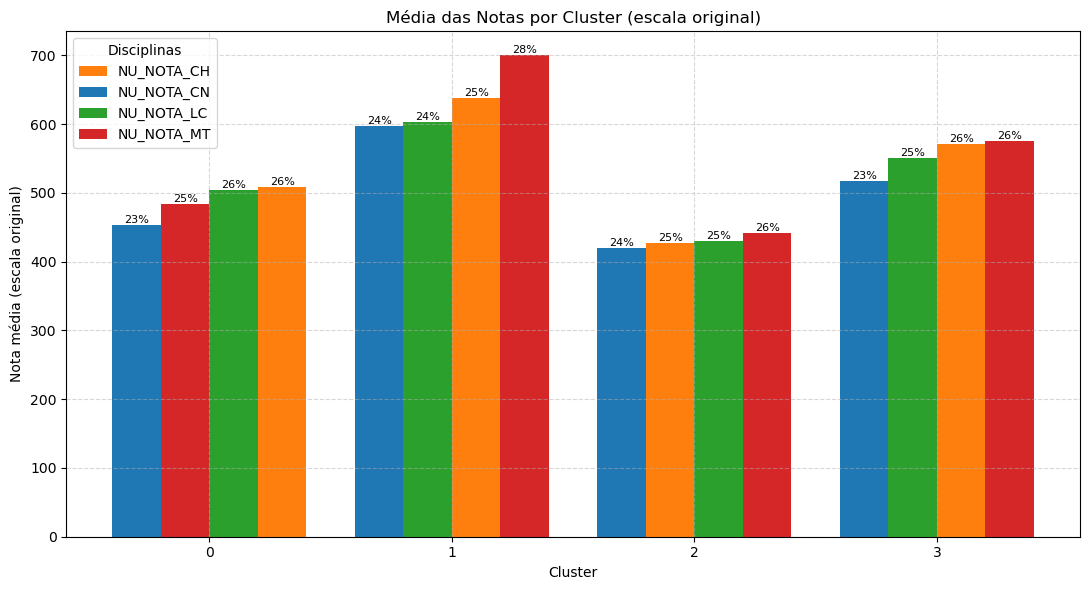

In [32]:
notas_orig = notas.copy()
notas_orig["Cluster"] = labels_final 

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

resumo_mean = notas_orig.groupby("Cluster")[colunas_notas].mean()

long = (
    resumo_mean.reset_index()
    .melt(id_vars="Cluster", var_name="Disciplina", value_name="Valor")
)

# 🔹 Percentual de cada disciplina dentro do cluster (soma = 100% por cluster)
long["Percent"] = (
    long.groupby("Cluster")["Valor"]
        .transform(lambda s: s / s.sum() * 100)
)

# ============================================
# 4️⃣ Define ranking das disciplinas dentro do cluster
# ============================================
long["Rank"] = (
    long.groupby("Cluster")["Valor"]
        .rank(method="first", ascending=True)
        .astype(int)
)

# ============================================
# 5️⃣ Cores e espaçamento
# ============================================
palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
disciplinas = long["Disciplina"].unique().tolist()
cores = {d: palette[i % len(palette)] for i, d in enumerate(disciplinas)}

clusters = sorted(long["Cluster"].unique().tolist())
n_vars = long["Disciplina"].nunique()
width = 0.8 / n_vars 

centros = {c: i for i, c in enumerate(clusters)}
offsets = {r: (r - (n_vars + 1) / 2) * width for r in range(1, n_vars + 1)}

long["x"] = long["Cluster"].map(centros) + long["Rank"].map(offsets)

# ============================================
# 6️⃣ Gráfico final + rótulos em %
# ============================================
fig, ax = plt.subplots(figsize=(11, 6))

bar_info = {}  # p/ ligar barras aos dados

for disc, sub in long.groupby("Disciplina"):
    bars = ax.bar(sub["x"], sub["Valor"], width=width, label=disc, color=cores[disc])
    bar_info[disc] = (bars, sub)

# 🔹 Escreve a % em cada barrinha (dentro de cada cluster soma 100%)
for disc, (bars, sub) in bar_info.items():
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{row['Percent']:.0f}%",   # arredondado sem casa decimal
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(list(centros.values()))
ax.set_xticklabels([str(c) for c in clusters])

ax.legend(title="Disciplinas")
ax.set_title("Média das Notas por Cluster (escala original)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Nota média (escala original)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**

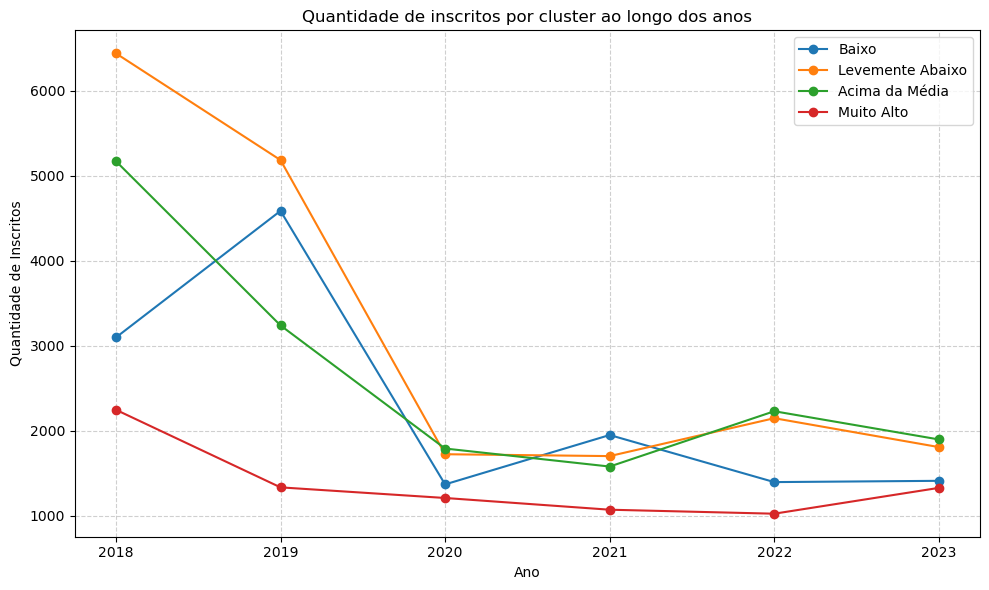

In [33]:
colunas_notas = ["NU_ANO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna().copy()

# Apenas as notas — sem criar a média
X = notas[["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]].values

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(Xz)

centers = kmeans_final.cluster_centers_          # centróides no espaço padronizado
centers_mean = centers.mean(axis=1)              # média de cada centróide (só para ordenar)
order = np.argsort(centers_mean)                 # do "pior" ao "melhor"

old_to_rank = {old_label: rank for rank, old_label in enumerate(order)}

rank_to_name = {
    0: "Baixo",
    1: "Levemente Abaixo",
    2: "Acima da Média",
    3: "Muito Alto"
}

notas["Cluster"] = [rank_to_name[old_to_rank[l]] for l in labels]

contagem = (
    notas.groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

# Gráfico de linhas
plt.figure(figsize=(10,6))
for nome in ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]:
    df_plot = contagem[contagem["Cluster"] == nome]
    if not df_plot.empty:
        plt.plot(df_plot["NU_ANO"], df_plot["Quantidade"], marker="o", label=nome)

plt.title("Quantidade de inscritos por cluster ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Inscritos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## **Quantidade de inscritos por grupo**

In [34]:
tabela_clusters = (notas["Cluster"]
                   .value_counts()
                   .reindex(["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"])
                   .reset_index())

tabela_clusters.columns = ["Grupo", "Quantidade"]
total = int(tabela_clusters["Quantidade"].sum())
tabela_clusters["Porcentagem"] = (tabela_clusters["Quantidade"] / total * 100).round(1)

# linha total
linha_total = pd.DataFrame({
    "Grupo": ["Total"],
    "Quantidade": [total],
    "Porcentagem": [100.0]
})
tabela_final = pd.concat([tabela_clusters, linha_total], ignore_index=True)

# formatação apenas para exibir
tabela_final_fmt = tabela_final.copy()
tabela_final_fmt["Quantidade"] = tabela_final_fmt["Quantidade"].map(lambda x: f"{x:,}".replace(",", "."))
tabela_final_fmt["Porcentagem"] = tabela_final_fmt["Porcentagem"].map(lambda x: f"{x:.0f}%")

print(tabela_final_fmt)

              Grupo Quantidade Porcentagem
0             Baixo     13.812         24%
1  Levemente Abaixo     19.010         33%
2    Acima da Média     15.911         28%
3        Muito Alto      8.213         14%
4             Total     56.946        100%


## **Quantidade de inscritos por grupo entre 2018 e 2023**

In [35]:
contagem = (notas.groupby(["NU_ANO", "Cluster"])
                 .size()
                 .reset_index(name="Quantidade"))

tabela = (contagem.pivot(index="NU_ANO", columns="Cluster", values="Quantidade")
                  .reindex(columns=["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"])
                  .fillna(0)
                  .astype(int)
          ).sort_index()

tabela_fmt = tabela.copy()
tabela_fmt["Total"] = tabela_fmt.sum(axis=1)

try:
    tabela_fmt = tabela_fmt.map(lambda x: f"{x:,}".replace(",", "."))
except AttributeError:
    tabela_fmt = tabela_fmt.apply(lambda col: col.map(lambda x: f"{x:,}".replace(",", ".")))

print("\nTabela formatada:")
print(tabela_fmt)


Tabela formatada:
Cluster  Baixo Levemente Abaixo Acima da Média Muito Alto   Total
NU_ANO                                                           
2018     3.098            6.442          5.173      2.247  16.960
2019     4.588            5.186          3.240      1.334  14.348
2020     1.369            1.724          1.791      1.209   6.093
2021     1.950            1.702          1.579      1.071   6.302
2022     1.396            2.148          2.230      1.024   6.798
2023     1.411            1.808          1.898      1.328   6.445


## **Média e Desvio Padrão das notas por grupo entre 2018 e 2023.**

In [36]:
cols_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
ordem_clusters = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

agg = (
    notas[notas["Cluster"].isin(ordem_clusters)]
      .groupby(["NU_ANO","Cluster"])[cols_notas]
      .mean()
      .round(1)
      .reset_index()
)

wide = (
    agg.pivot(index="NU_ANO", columns="Cluster", values=cols_notas)
       .reindex(columns=pd.MultiIndex.from_product([cols_notas, ordem_clusters]))
       .sort_index()
)

# Renomeia colunas com abreviações
abrevs = {
    "NU_NOTA_CN": "Ciên. Nat.",
    "NU_NOTA_CH": "Ciên. Hum.",
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática"
}

def rotulo(col):
    disciplina, cluster = col
    return f"{abrevs[disciplina]} - {cluster}"

wide.columns = [rotulo(c) for c in wide.columns]
wide.index.name = "Ano"

tabela_fmt = wide.copy().applymap(lambda x: str(x).replace(".", ","))
print("\nMédia das notas por disciplina, ano e cluster:")
print(tabela_fmt)


Média das notas por disciplina, ano e cluster:
     Ciên. Nat. - Baixo Ciên. Nat. - Levemente Abaixo  \
Ano                                                     
2018              429,8                         451,8   
2019              409,0                         446,2   
2020              420,5                         453,8   
2021              423,4                         461,4   
2022              435,4                         460,8   
2023              416,9                         466,8   

     Ciên. Nat. - Acima da Média Ciên. Nat. - Muito Alto Ciên. Hum. - Baixo  \
Ano                                                                           
2018                       509,5                   594,5              459,2   
2019                       519,2                   590,7              414,9   
2020                       525,6                   600,2              407,0   
2021                       524,3                   605,1              422,4   
2022                 

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_16572\3709129096.py:33: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_fmt = wide.copy().applymap(lambda x: str(x).replace(".", ","))


## **Quantidade de inscritos por grupo para cada tipo de escola**

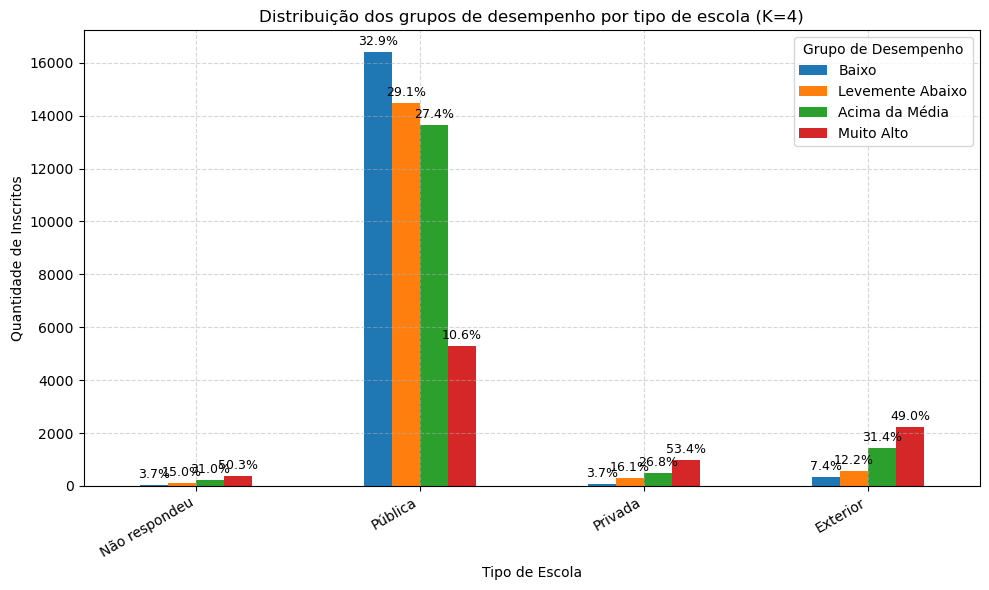


Resumo total de inscritos por grupo de desempenho:
                  Quantidade  Porcentagem
Cluster                                  
Baixo                  16840         29.6
Levemente Abaixo       15432         27.1
Acima da Média         15799         27.7
Muito Alto              8875         15.6


In [37]:
cols = ["TP_ESCOLA", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
base = df_ifnmg[cols].dropna().copy()

# Define a ordem dos tipos de escola conforme os códigos originais
ordem_escola = [1, 2, 4, 3]  # 1: Não respondeu, 2: Pública, 4: Privada, 3: Exterior
base["TP_ESCOLA"] = pd.Categorical(base["TP_ESCOLA"], categories=ordem_escola, ordered=True)

# Cria base de notas
X = base[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].values

# --- Executa K-Means com k=4 ---
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Ordena clusters pela média dos centróides
centers = kmeans.cluster_centers_
centers_mean = centers.mean(axis=1)
ordem_por_media = np.argsort(centers_mean)

# Mapeia a ordem para rótulos
rank_map = {lab: rank for rank, lab in enumerate(ordem_por_media)}
nomes = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

base["Cluster"] = pd.Categorical(
    [nomes[rank_map[l]] for l in cluster_labels],
    categories=nomes, ordered=True
)

# --- Contagem de participantes por tipo de escola e cluster ---
contagem = (
    base.groupby(["TP_ESCOLA", "Cluster"], observed=True)
        .size()
        .rename("Quantidade")
        .reset_index()
)

# Cria tabela formatada
tabela = (
    contagem.pivot_table(
        index="TP_ESCOLA", columns="Cluster", values="Quantidade",
        aggfunc="sum", observed=True
    )
    .reindex(index=ordem_escola, columns=nomes)
    .fillna(0)
    .astype(int)
)

# Substitui códigos por rótulos descritivos
mapa_escola = {
    1: "Não respondeu",
    2: "Pública",
    3: "Exterior",
    4: "Privada"
}
tabela.index = [mapa_escola.get(i, i) for i in tabela.index]

# --- Calcula % por tipo de escola ---
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# --- Gráfico ---
ax = tabela.plot(kind="bar", figsize=(10, 6))
ax.set_title("Distribuição dos grupos de desempenho por tipo de escola (K=4)")
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")

# Exibe porcentagens sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# --- (Opcional) Tabela resumo total ---
tabela_total = tabela.sum().to_frame(name="Quantidade")
tabela_total["Porcentagem"] = (tabela_total["Quantidade"] / tabela_total["Quantidade"].sum() * 100).round(1)
print("\nResumo total de inscritos por grupo de desempenho:")
print(tabela_total)


Entre os estudantes de escolas públicas, observa-se uma forte concentração nos grupos Baixo (32,9%) e Levemente Abaixo (29,1%), totalizando cerca de 62% dos participantes com desempenho inferior à média geral. Ainda assim, 27,4% estão no grupo Acima da Média e 10,6% no grupo Muito Alto, evidenciando a presença de alunos com bom desempenho mesmo dentro do sistema público.

Nas escolas privadas, o cenário se inverte: a maior parte dos estudantes pertence aos grupos de melhor desempenho — 53,4% estão em Muito Alto e 26,8% em Acima da Média, o que representa cerca de 80% dos participantes com rendimento acima da média. Apenas 3,7% estão no grupo Baixo e 16,1% em Levemente Abaixo.

Entre os estudantes do exterior, há uma predominância ainda maior de alto desempenho: 49,0% estão no grupo Muito Alto e 31,4% em Acima da Média, totalizando mais de 80% acima da média geral.

Já na categoria “Não respondeu”, a amostra é reduzida, mas também apresenta predominância nos grupos de menor desempenho.

## **Quantidade de inscritos por grupo para cada gênero**


Tabela (Sexo × Cluster) – numérica:
Cluster    Baixo  Levemente Abaixo  Acima da Média  Muito Alto  Total
Feminino    8923             12528            9112        3960  34523
Masculino   4889              6482            6799        4253  22423
Total      13812             19010           15911        8213  56946


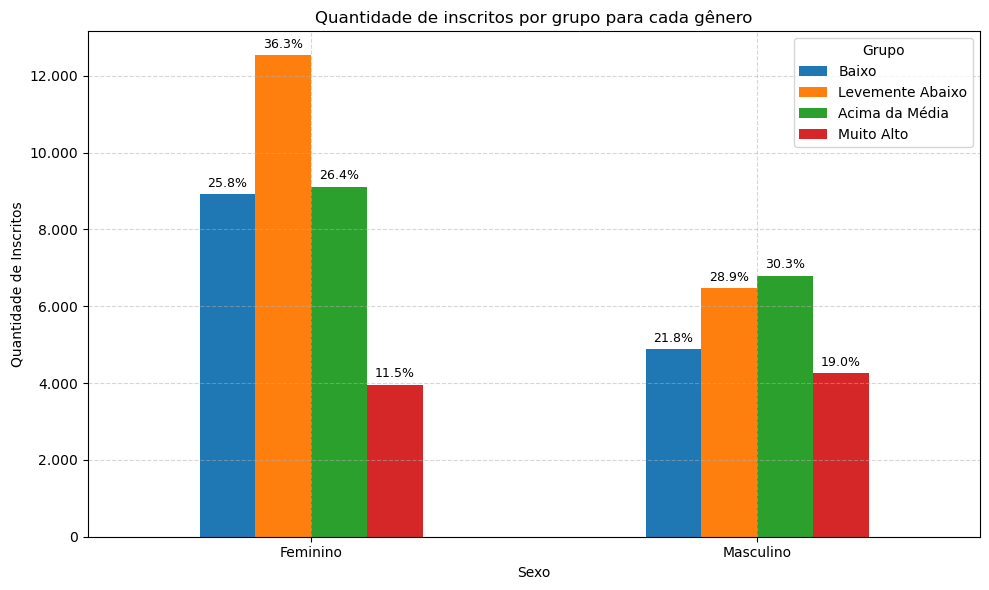

In [38]:
colunas_notas = ["TP_SEXO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna().copy()

if "Cluster" not in notas.columns:
    X = notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].values
    Xz = StandardScaler().fit_transform(X)
    
    km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    order = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {0: "Baixo", 1: "Levemente Abaixo", 2: "Acima da Média", 3: "Muito Alto"}
    
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# Contagem de participantes por sexo e cluster
contagem_sexo = (
    notas.groupby(["TP_SEXO", "Cluster"], observed=True)
         .size()
         .reset_index(name="Quantidade")
)

ordem_clusters = ["Baixo", "Levemente Abaixo", "Acima da Média", "Muito Alto"]

tabela = (
    contagem_sexo.pivot_table(
        index="TP_SEXO", columns="Cluster",
        values="Quantidade", aggfunc="sum", observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

# Ajusta rótulos de sexo
def rotulo_sexo(v):
    return {
        0: "Feminino", 1: "Masculino",
        "0": "Feminino", "1": "Masculino",
        "F": "Feminino", "M": "Masculino"
    }.get(v, str(v))

tabela.index = [rotulo_sexo(i) for i in tabela.index]

# Adiciona totais
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela (Sexo × Cluster) – numérica:")
print(tabela_tot)

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# Gráfico
ax = tabela.plot(kind="bar", figsize=(10, 6))
ax.set_title("Quantidade de inscritos por grupo para cada gênero")
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo")
ax.set_xticklabels(tabela.index, rotation=0)

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

ax.grid(True, linestyle="--", alpha=0.5)

# 🔹 Colocar a % em cada barrinha
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]                # nome do cluster (Baixo, etc.)
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Entre os participantes do gênero feminino, observa-se uma distribuição mais concentrada nos grupos Levemente Abaixo (36,3%) e Acima da Média (26,4%). Já o grupo Baixo representa 25,8% das estudantes, enquanto 11,5% alcançam o grupo Muito Alto.
Esse padrão sugere que o desempenho das mulheres tende a se concentrar nos níveis intermediários, com presença relevante nos grupos de rendimento acima da média, embora ainda limitada no grupo de excelência (Muito Alto).

Por outro lado, entre os participantes do gênero masculino, há uma maior presença nos níveis superiores: 30,3% estão no grupo Acima da Média e 19,0% no Muito Alto, totalizando quase metade dos homens (49,3%) com desempenho acima da média.
Nos níveis inferiores, 28,9% encontram-se no grupo Levemente Abaixo e 21,8% no grupo Baixo.

De forma geral, o gráfico evidencia que os homens apresentam uma leve vantagem nos grupos de maior desempenho, enquanto as mulheres se destacam nos níveis intermediários, especialmente no grupo Levemente Abaixo.
Essa diferença pode refletir variações de perfil de estudo, autoconfiança em áreas específicas das provas ou disparidades no acesso a recursos e estratégias de aprendizagem.

Em síntese, os resultados indicam que, embora o desempenho feminino se concentre em torno da média, o grupo masculino mostra maior representatividade nos níveis mais altos, o que sugere uma assimetria moderada de desempenho entre os gêneros.

## **Quantidade de inscritos por grupo para cada cor/raça**


Tabela Raça × Cluster (numérica):
Cluster        Baixo  Levemente Abaixo  Acima da Média  Muito Alto  Total
Não declarado    188               245             235         162    830
Branca          2384              3819            4213        3186  13602
Preta           2104              2871            2012         685   7672
Parda           8693             11466            9103        4040  33302
Amarela          316               501             298         133   1248
Indígena         127               108              50           7    292
Total          13812             19010           15911        8213  56946


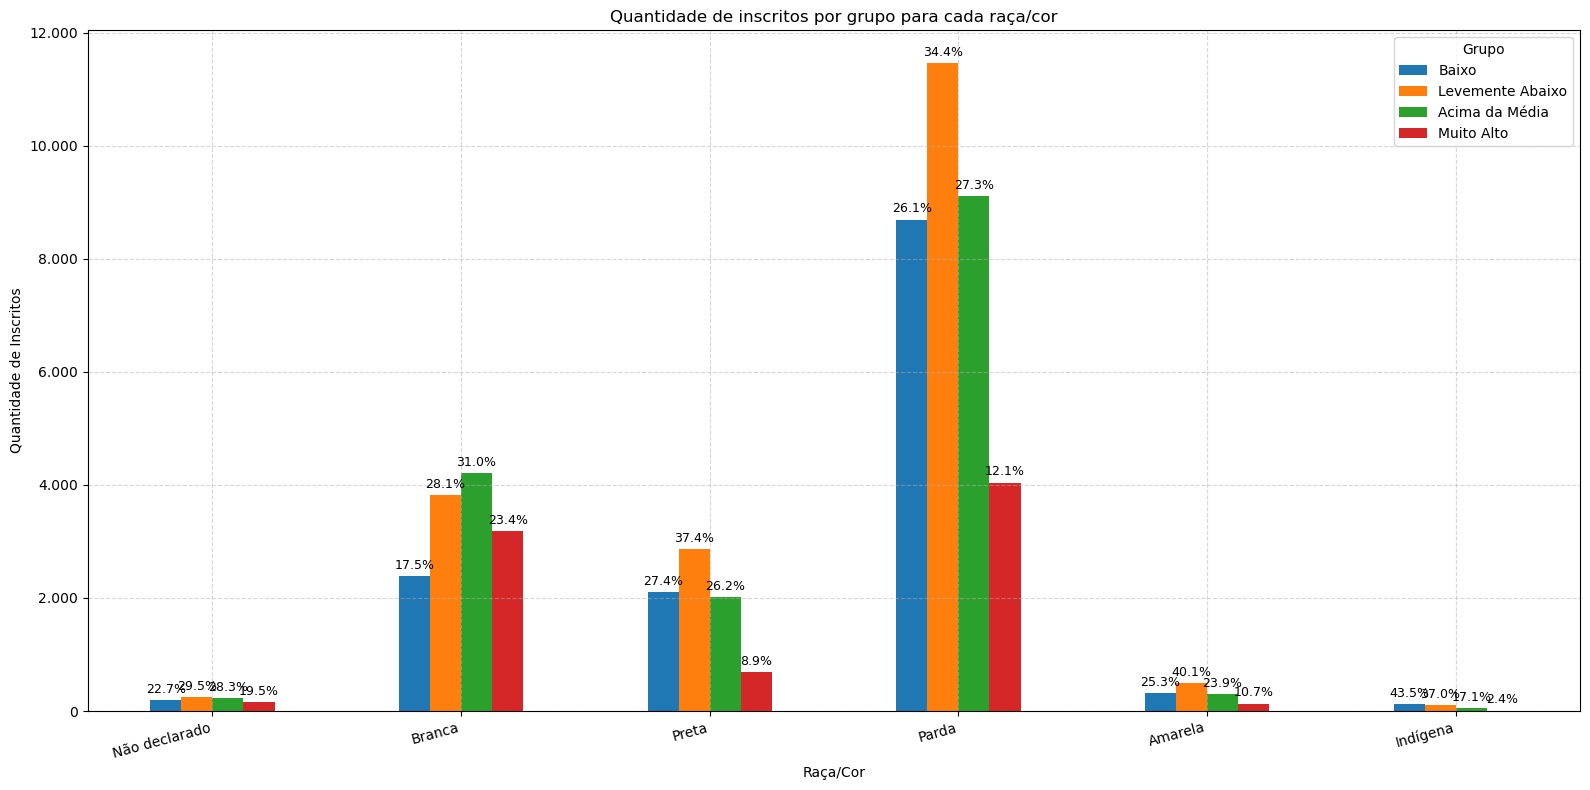

In [39]:
base = df_ifnmg.copy() if 'df_ifnmg' in globals() else df_final.copy()

# Garante que exista a coluna TP_COR_RACA
if "TP_COR_RACA" not in base.columns:
    dummy_cols = [c for c in base.columns if c.startswith("COR_RACA_")]
    if not dummy_cols:
        raise ValueError("Não encontrei TP_COR_RACA nem colunas COR_RACA_* na base.")
    base["TP_COR_RACA"] = (
        base[dummy_cols]
        .idxmax(axis=1)
        .str.replace("COR_RACA_", "", regex=False)
        .astype(int)
    )

# Seleciona apenas as notas e a variável de raça/cor
cols_notas = ["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]
notas = base[["TP_COR_RACA"] + cols_notas].dropna(subset=cols_notas).copy()

if "Cluster" not in notas.columns:
    Xz = StandardScaler().fit_transform(notas[cols_notas].values)
    km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    order = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {0:"Baixo", 1:"Levemente Abaixo", 2:"Acima da Média", 3:"Muito Alto"}
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# Contagem de alunos por raça e cluster
contagem_raca = (
    notas.groupby(["TP_COR_RACA","Cluster"])
         .size()
         .reset_index(name="Quantidade")
)

ordem_raca = [0,1,2,3,4,5]  # ajuste se quiser outra ordem
ordem_clusters = ["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"]

tabela = (
    contagem_raca.pivot(index="TP_COR_RACA", columns="Cluster", values="Quantidade")
                 .reindex(index=[r for r in ordem_raca if r in contagem_raca["TP_COR_RACA"].unique()],
                          columns=ordem_clusters)
                 .fillna(0).astype(int)
)

# Mapeia rótulos de raça/cor
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
}
tabela.index = [mapa_raca[i] for i in tabela.index]

# Adiciona total por linha e coluna
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela Raça × Cluster (numérica):")
print(tabela_tot)

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))  
tabela.plot(kind="bar", ax=ax)

ax.set_title("Quantidade de inscritos por grupo para cada raça/cor")
ax.set_xlabel("Raça/Cor")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")

ax.legend(title="Grupo")

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))
ax.grid(True, linestyle="--", alpha=0.5)

# Rótulos de % em cada barra
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]  # Baixo / Levemente Abaixo / ...
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Entre os estudantes que se declaram brancos, observa-se uma distribuição relativamente mais favorável: cerca de 31% estão no grupo Acima da Média e aproximadamente 24% no grupo Muito Alto. Somando esses dois grupos, mais da metade dos estudantes brancos se encontra em níveis de desempenho acima da média. A participação nos grupos Baixo e Levemente Abaixo é menor quando comparada a outras categorias.

Entre os estudantes pretos e pardos, percebe-se maior concentração nos grupos de desempenho inferiores. Para os pretos, algo em torno de 27% está no grupo Baixo e cerca de 38% em Levemente Abaixo, enquanto apenas uma parcela bem menor atinge o grupo Muito Alto. Entre os pardos, a maior parte também se concentra em Baixo e Levemente Abaixo, com proporção menor nos níveis superiores quando comparados aos brancos.

Nos estudantes amarelos, a distribuição é mais concentrada nos grupos intermediários, especialmente Levemente Abaixo, com uma fatia mais modesta em Muito Alto. Já entre os indígenas, a proporção no grupo Baixo é bastante elevada, e a presença nos níveis Acima da Média e Muito Alto é bem menor, indicando um cenário de maior vulnerabilidade educacional.


Para o grupo não declarado, as porcentagens se distribuem de maneira intermediária, sem um destaque claro em desempenho muito alto, o que pode estar ligado tanto ao perfil dos estudantes quanto a possíveis particularidades dessa categoria (por exemplo, tamanho de amostra menor ou perfis heterogêneos).

De forma geral, o gráfico evidencia que estudantes brancos tendem a ter maior participação nos grupos de melhor desempenho, enquanto estudantes pretos, pardos, amarelos e indígenas estão proporcionalmente mais concentrados nos níveis abaixo da média.

## **Quantidade de inscritos por grupo para cada faixa de renda mensal**

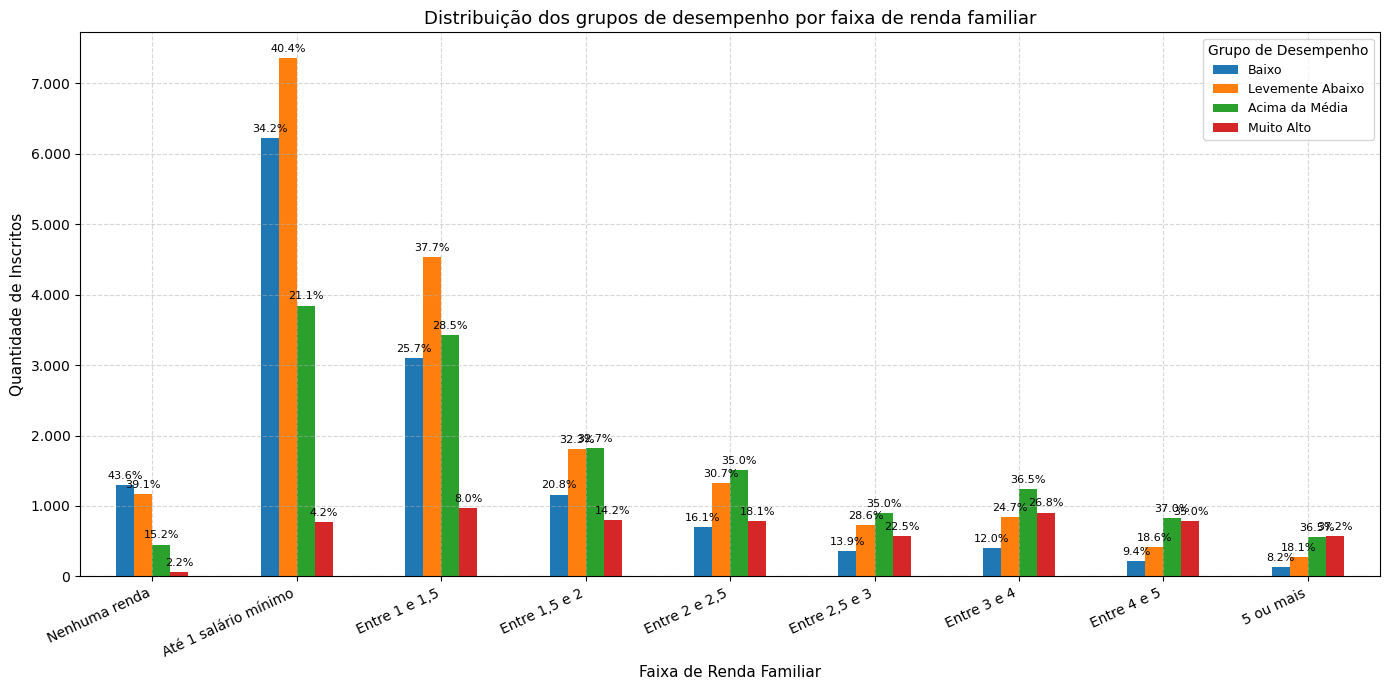

In [40]:
base = df_ifnmg.copy()

# Garante que exista a coluna RENDA_MENSAL
if "RENDA_MENSAL" not in base.columns:
    renda_dummies = [c for c in base.columns if c.startswith("RENDA_MENSAL_")]
    if not renda_dummies:
        raise ValueError("Não encontrei coluna 'RENDA_MENSAL' nem dummies 'RENDA_MENSAL_*'.")
    base["RENDA_MENSAL"] = (
        base[renda_dummies].idxmax(axis=1)
                           .str.replace("RENDA_MENSAL_", "", regex=False)
    )

# Seleciona notas e renda
cols_notas = ["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]
notas = base[["RENDA_MENSAL"] + cols_notas].dropna(subset=cols_notas).copy()

# Clusters pelas notas
if "Cluster" not in notas.columns:
    Xz = StandardScaler().fit_transform(notas[cols_notas].values)
    km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    ordem = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(ordem)}
    rank2name = {0:"Baixo", 1:"Levemente Abaixo", 2:"Acima da Média", 3:"Muito Alto"}
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# 🔹 Mapeia letras para faixas reais de renda
mapa_renda = {
    "A": "Nenhuma renda",
    "B": "Até 1 salário mínimo",
    "C": "Entre 1 e 1,5",
    "D": "Entre 1,5 e 2",
    "E": "Entre 2 e 2,5",
    "F": "Entre 2,5 e 3",
    "G": "Entre 3 e 4",
    "H": "Entre 4 e 5",
    "I": "5 ou mais"
}

# Substitui letras por descrições (remove demais letras)
notas = notas[notas["RENDA_MENSAL"].isin(mapa_renda.keys())].copy()
notas["Faixa_Renda"] = notas["RENDA_MENSAL"].map(mapa_renda)

# Agrupa e calcula contagem
contagem_renda = (
    notas.groupby(["Faixa_Renda","Cluster"])
         .size()
         .reset_index(name="Quantidade")
)

ordem_clusters = ["Baixo","Levemente Abaixo","Acima da Média","Muito Alto"]
ordem_renda = [
    "Nenhuma renda",
    "Até 1 salário mínimo",
    "Entre 1 e 1,5",
    "Entre 1,5 e 2",
    "Entre 2 e 2,5",
    "Entre 2,5 e 3",
    "Entre 3 e 4",
    "Entre 4 e 5",
    "5 ou mais"
]

# Cria tabela formatada
tabela = (
    contagem_renda.pivot(index="Faixa_Renda", columns="Cluster", values="Quantidade")
                  .reindex(index=ordem_renda, columns=ordem_clusters)
                  .fillna(0).astype(int)
)

# Calcula percentuais
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# 🔹 Gráfico
fig, ax = plt.subplots(figsize=(14,7))
tabela.plot(kind="bar", ax=ax)

ax.set_title("Distribuição dos grupos de desempenho por faixa de renda familiar", fontsize=13)
ax.set_xlabel("Faixa de Renda Familiar", fontsize=11)
ax.set_ylabel("Quantidade de Inscritos", fontsize=11)
ax.set_xticklabels(tabela.index, rotation=25, ha="right")
ax.legend(title="Grupo de Desempenho", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# Formata eixo y com separador de milhar
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

# Adiciona rótulos de percentual em cada barra
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()

**1. Faixas de renda mais baixas – até 1,5 salário mínimo**

Entre os estudantes com nenhuma renda ou até 1 salário mínimo, há forte concentração nos grupos de desempenho mais baixos.

Na faixa até 1 salário mínimo, 40,6% dos inscritos estão no grupo Levemente Abaixo e 33,4% no grupo Baixo, somando cerca de 74% abaixo da média.

Apenas 21,7% estão Acima da Média e 4,3% no grupo Muito Alto, o que evidencia uma grande desigualdade de desempenho associada à renda.

Entre os estudantes sem renda, o padrão é semelhante: 42,9% estão no grupo Baixo e apenas 2,2% no Muito Alto.

**2. Renda intermediária – entre 1,5 e 3 salários mínimos**

Nas faixas intermediárias, o desempenho melhora de forma gradual.

Os grupos Acima da Média passam a ganhar representatividade, chegando a 35,3% entre os alunos com renda de 2 a 2,5 salários mínimos.

Observa-se uma redução progressiva da proporção de alunos no grupo Baixo, que cai de mais de 40% nas faixas iniciais para cerca de 15% nas rendas entre 2 e 3 salários.
Isso sugere que o aumento da renda familiar está diretamente relacionado a melhores condições de desempenho escolar.

**3. Renda mais alta – acima de 3 salários mínimos**

Nas faixas de renda mais altas, o cenário se inverte.

A participação nos grupos de melhor desempenho (Acima da Média e Muito Alto) supera 50% em praticamente todas as categorias a partir de 3 salários mínimos.

Por exemplo, entre os alunos com renda de 3 a 4 salários, 36% estão Acima da Média e 27,3% no grupo Muito Alto, totalizando mais de 63% com desempenho acima da média.

O mesmo padrão se repete entre os que possuem renda superior a 4 salários, nos quais os grupos de baixo desempenho somam menos de 30%.



O gráfico evidencia uma relação direta entre renda e desempenho escolar:
quanto maior a renda familiar, menor a proporção de estudantes nos grupos de baixo desempenho e maior a concentração nos grupos de desempenho elevado.

Esses resultados reforçam o impacto das condições socioeconômicas sobre o desempenho acadêmico. Estudantes de famílias com menor renda tendem a enfrentar maiores desafios de acesso, infraestrutura, apoio pedagógico e recursos educacionais, o que se reflete nas notas.

Já nas faixas de renda mais altas, a melhor distribuição de recursos e oportunidades parece favorecer o desempenho, ampliando a proporção de alunos com resultados acima da média.

## **Analise dos Cluster para K=3**

## **Bisecting K-Means**

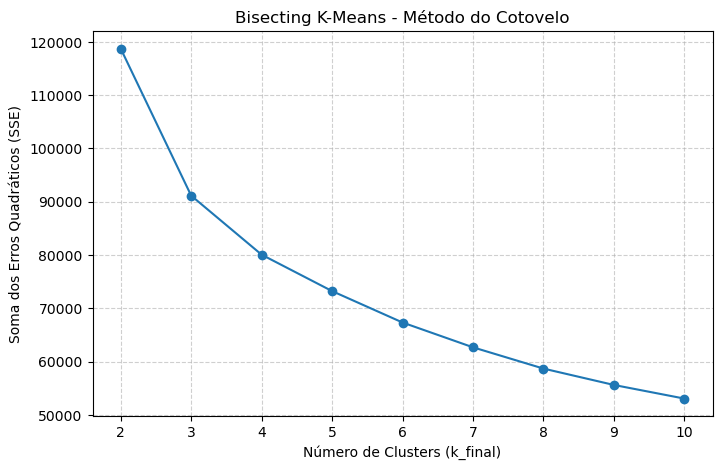

In [41]:
df_notas = df_ifnmg.copy()
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

notas = df_notas[colunas_notas].dropna()
scaler = StandardScaler()
X = scaler.fit_transform(notas)

def bisecting_kmeans(X, k_final=3, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)
    
    while len(clusters) < k_final:
        inertias = {i: KMeans(n_clusters=1, random_state=random_state).fit(X_cluster).inertia_
                    for i, X_cluster in clusters.items()}
        cluster_to_split = max(inertias, key=inertias.get)
        
        X_split = clusters[cluster_to_split]
        kmeans = KMeans(n_clusters=2, n_init=n_init, random_state=random_state)
        split_labels = kmeans.fit_predict(X_split)
        
        new_index = max(clusters.keys()) + 1
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_index] = X_split[split_labels == 1]
        
        mask = labels == cluster_to_split
        labels[mask] = np.where(split_labels == 0, cluster_to_split, new_index)
        
    return labels

resultados = []
intervalo_k = range(2, 11)  # testa de 2 a 10 clusters

for k in intervalo_k:
    labels = bisecting_kmeans(X, k_final=k)
    kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_final.fit(X)
    sse = kmeans_final.inertia_
    resultados.append(sse)

plt.figure(figsize=(8, 5))
plt.plot(intervalo_k, resultados, marker='o')
plt.title("Bisecting K-Means - Método do Cotovelo")
plt.xlabel("Número de Clusters (k_final)")
plt.ylabel("Soma dos Erros Quadráticos (SSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

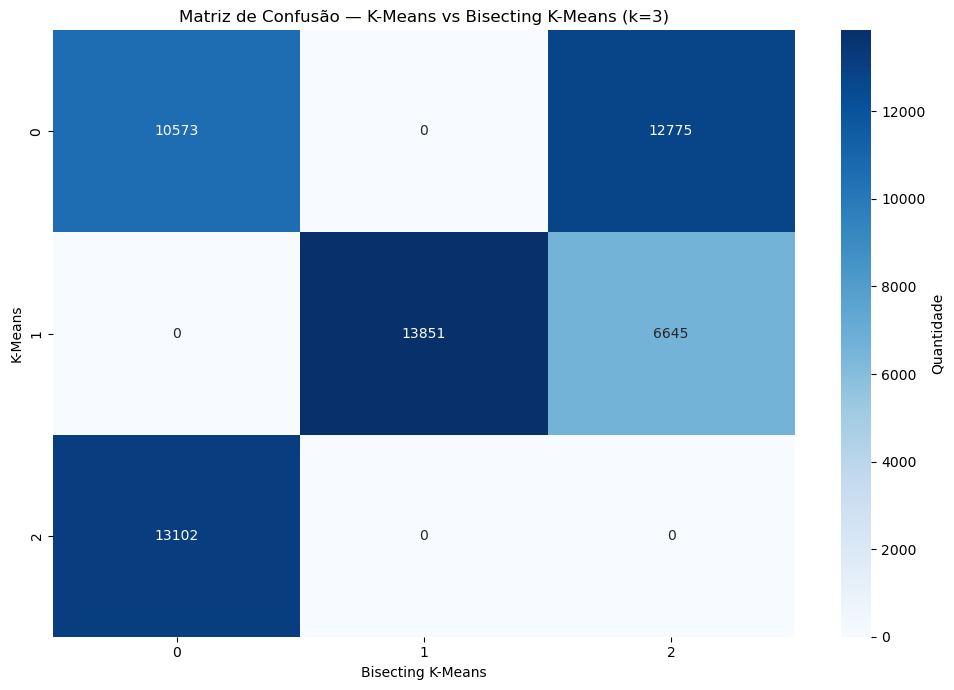

In [58]:
df_notas = df_ifnmg.copy()
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

notas = df_notas[colunas_notas].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(notas)

def bisecting_kmeans(X, k_final=4, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)
    
    while len(clusters) < k_final:
        inertias = {
            i: KMeans(n_clusters=1, random_state=random_state).fit(X_cluster).inertia_
            for i, X_cluster in clusters.items()
        }
        
        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]
        
        kmeans = KMeans(n_clusters=2, n_init=n_init, random_state=random_state)
        split_labels = kmeans.fit_predict(X_split)
        
        new_index = max(clusters.keys()) + 1
        
        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_index] = X_split[split_labels == 1]
        
        mask = labels == cluster_to_split
        labels[mask] = np.where(split_labels == 0, cluster_to_split, new_index)
        
    return labels


k_escolhido = 3

labels_bisect = bisecting_kmeans(X, k_final=k_escolhido)

kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X)

# ================================================================
# Matriz de Confusão entre K-Means e Bisecting K-Means
# ================================================================
cm = confusion_matrix(labels_kmeans, labels_bisect)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar_kws={'label': 'Quantidade'})
plt.xlabel("Bisecting K-Means")
plt.ylabel("K-Means")
plt.title(f"Matriz de Confusão — K-Means vs Bisecting K-Means (k={k_escolhido})")
plt.tight_layout()
plt.show()


## **Análise dos Clusters**

Médias e desvios por cluster (padronizadas):
        NU_NOTA_CN       NU_NOTA_CH       NU_NOTA_LC       NU_NOTA_MT      
              mean   std       mean   std       mean   std       mean   std
Cluster                                                                    
0            -0.01  0.65       0.19  0.59       0.21  0.54      -0.06  0.67
1            -0.78  0.63      -0.94  0.68      -0.94  0.72      -0.75  0.58
2             1.25  0.67       1.12  0.56       1.10  0.57       1.28  0.69


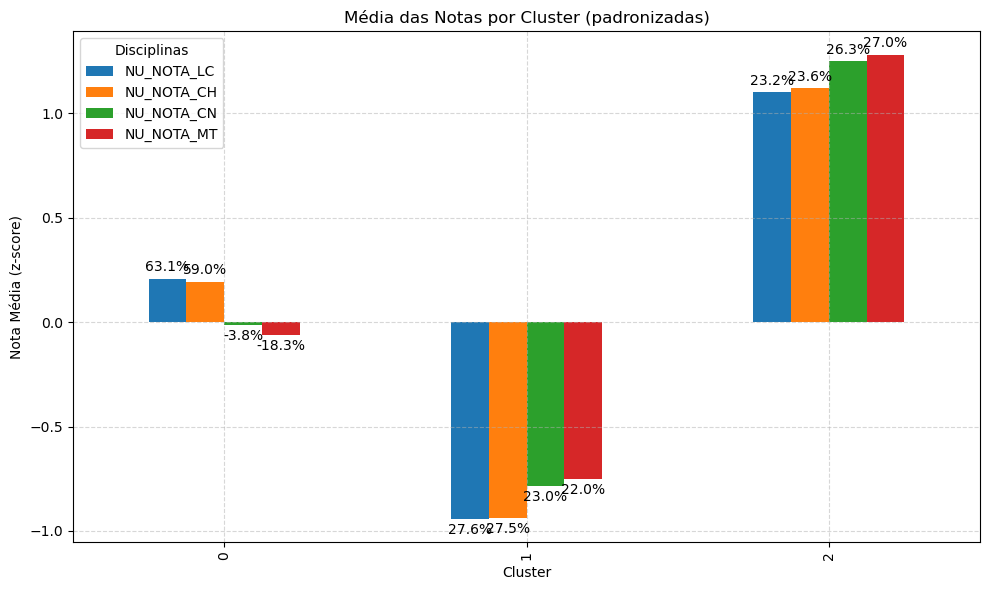

In [42]:
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna().copy()

# ===============================
# 1️⃣ Normalização das notas
# ===============================
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    index=notas.index,
    columns=colunas_notas
)

# ===============================
# 2️⃣ K-Means e agrupamento
# ===============================
k = 3
kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(df_norm)

df_norm["Cluster"] = labels_final

# ===============================
# 3️⃣ Resumo estatístico dos clusters
# ===============================
resumo_clusters = (
    df_norm.groupby("Cluster")[colunas_notas]
    .agg(["mean", "std"])
    .round(2)
)
print("Médias e desvios por cluster (padronizadas):")
print(resumo_clusters)

# ===============================
# 4️⃣ Gráfico ordenado pelas médias das disciplinas
# ===============================
resumo_mean = df_norm.groupby("Cluster")[colunas_notas].mean()

# Ordena colunas (disciplinas) do menor para o maior valor médio
ordem_cols = resumo_mean.mean(axis=0).sort_values(ascending=True).index
resumo_sorted = resumo_mean[ordem_cols]

# 👉 Calcula a porcentagem de cada disciplina dentro de cada cluster
# (cada linha = 1 cluster; a soma das 4 disciplinas ≈ 100%)
percent_df = resumo_sorted.div(resumo_sorted.sum(axis=1), axis=0) * 100

# Gráfico com os valores padronizados (z-score)
ax = resumo_sorted.plot(kind="bar", figsize=(10, 6))
plt.title("Média das Notas por Cluster (padronizadas)")
plt.xlabel("Cluster")
plt.ylabel("Nota Média (z-score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Disciplinas")

# 🔹 Colocando as porcentagens (1 casa decimal) sobre cada barrinha
for i, container in enumerate(ax.containers):
    col = resumo_sorted.columns[i]  # disciplina correspondente
    labels = [f"{percent_df.loc[cluster, col]:.1f}%" 
              for cluster in resumo_sorted.index]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

### **Análise dos clusters com as notas sem normalizar**

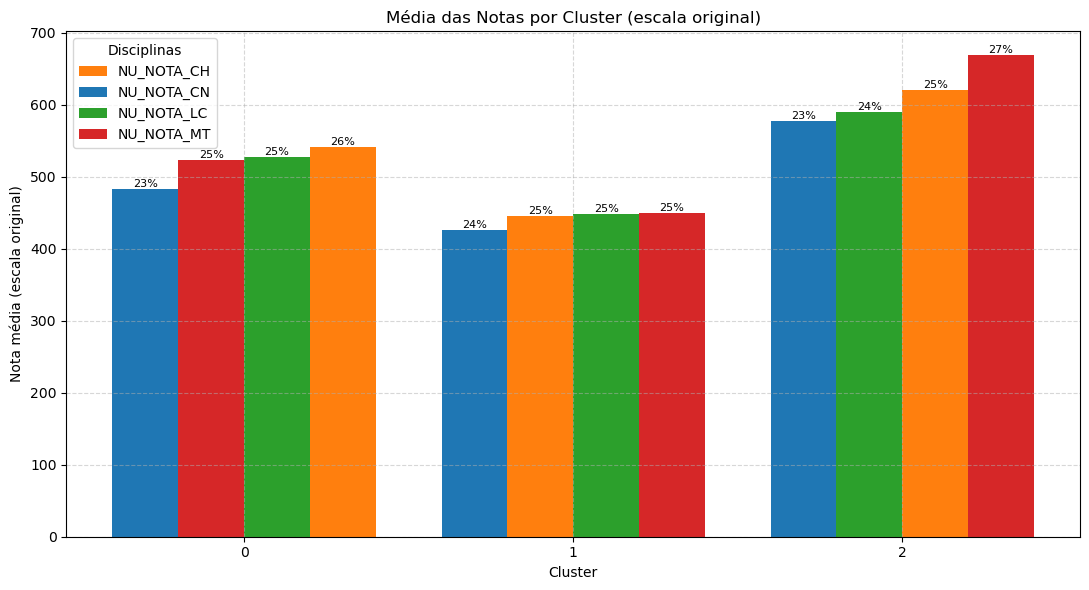

In [43]:
notas_orig = notas.copy()
notas_orig["Cluster"] = labels_final 

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

resumo_mean = notas_orig.groupby("Cluster")[colunas_notas].mean()

long = (
    resumo_mean.reset_index()
    .melt(id_vars="Cluster", var_name="Disciplina", value_name="Valor")
)

# 🔹 Percentual de cada disciplina dentro do cluster (soma = 100% por cluster)
long["Percent"] = (
    long.groupby("Cluster")["Valor"]
        .transform(lambda s: s / s.sum() * 100)
)

# ============================================
# 4️⃣ Define ranking das disciplinas dentro do cluster
# ============================================
long["Rank"] = (
    long.groupby("Cluster")["Valor"]
        .rank(method="first", ascending=True)
        .astype(int)
)

# ============================================
# 5️⃣ Cores e espaçamento
# ============================================
palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
disciplinas = long["Disciplina"].unique().tolist()
cores = {d: palette[i % len(palette)] for i, d in enumerate(disciplinas)}

clusters = sorted(long["Cluster"].unique().tolist())
n_vars = long["Disciplina"].nunique()
width = 0.8 / n_vars 

centros = {c: i for i, c in enumerate(clusters)}
offsets = {r: (r - (n_vars + 1) / 2) * width for r in range(1, n_vars + 1)}

long["x"] = long["Cluster"].map(centros) + long["Rank"].map(offsets)

# ============================================
# 6️⃣ Gráfico final + rótulos em %
# ============================================
fig, ax = plt.subplots(figsize=(11, 6))

bar_info = {}  # p/ ligar barras aos dados

for disc, sub in long.groupby("Disciplina"):
    bars = ax.bar(sub["x"], sub["Valor"], width=width, label=disc, color=cores[disc])
    bar_info[disc] = (bars, sub)

# 🔹 Escreve a % em cada barrinha (dentro de cada cluster soma 100%)
for disc, (bars, sub) in bar_info.items():
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{row['Percent']:.0f}%",   # arredondado sem casa decimal
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(list(centros.values()))
ax.set_xticklabels([str(c) for c in clusters])

ax.legend(title="Disciplinas")
ax.set_title("Média das Notas por Cluster (escala original)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Nota média (escala original)")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**

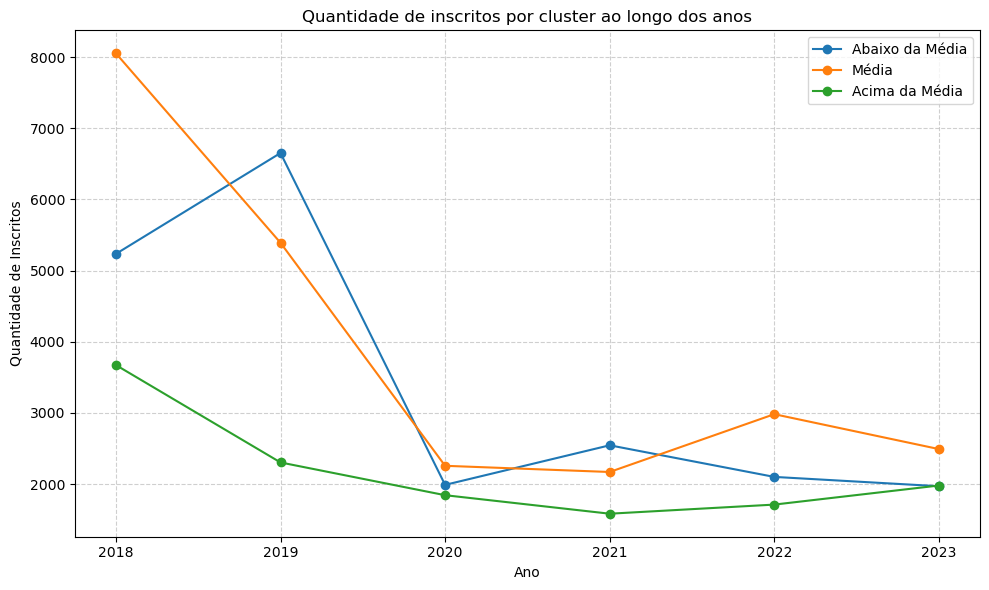

In [44]:
colunas_notas = ["NU_ANO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna().copy()

# Apenas as notas — sem criar a média
X = notas[["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]].values

scaler = StandardScaler()
Xz = scaler.fit_transform(X)

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(Xz)

centers = kmeans_final.cluster_centers_          # centróides no espaço padronizado
centers_mean = centers.mean(axis=1)              # média de cada centróide (só para ordenar)
order = np.argsort(centers_mean)                 # do "pior" ao "melhor"

old_to_rank = {old_label: rank for rank, old_label in enumerate(order)}

rank_to_name = {
    0: "Abaixo da Média",
    1: "Média",
    2: "Acima da Média"
}

notas["Cluster"] = [rank_to_name[old_to_rank[l]] for l in labels]

contagem = (
    notas.groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

# Gráfico de linhas
plt.figure(figsize=(10,6))
for nome in ["Abaixo da Média", "Média", "Acima da Média"]:
    df_plot = contagem[contagem["Cluster"] == nome]
    if not df_plot.empty:
        plt.plot(df_plot["NU_ANO"], df_plot["Quantidade"], marker="o", label=nome)

plt.title("Quantidade de inscritos por cluster ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Inscritos")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### **Quantidade de inscritos por grupo**

In [45]:
tabela_clusters = (
    notas["Cluster"]
    .value_counts()
    .reindex(["Abaixo da Média", "Média", "Acima da Média"])  # novos nomes dos grupos
    .reset_index()
)

tabela_clusters.columns = ["Grupo", "Quantidade"]

# Calcula total e porcentagem
total = int(tabela_clusters["Quantidade"].sum())
tabela_clusters["Porcentagem"] = (tabela_clusters["Quantidade"] / total * 100).round(1)

# Adiciona linha total
linha_total = pd.DataFrame({
    "Grupo": ["Total"],
    "Quantidade": [total],
    "Porcentagem": [100.0]
})

tabela_final = pd.concat([tabela_clusters, linha_total], ignore_index=True)

# Formata apenas para exibição
tabela_final_fmt = tabela_final.copy()
tabela_final_fmt["Quantidade"] = tabela_final_fmt["Quantidade"].map(lambda x: f"{x:,}".replace(",", "."))
tabela_final_fmt["Porcentagem"] = tabela_final_fmt["Porcentagem"].map(lambda x: f"{x:.0f}%")

print(tabela_final_fmt)


             Grupo Quantidade Porcentagem
0  Abaixo da Média     20.496         36%
1            Média     23.348         41%
2   Acima da Média     13.102         23%
3            Total     56.946        100%


### **Quantidade de inscritos por grupo entre 2018 e 2023**

In [46]:
contagem = (
    notas.groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

# Pivot com as três categorias do K=3
tabela = (
    contagem.pivot(index="NU_ANO", columns="Cluster", values="Quantidade")
    .reindex(columns=["Abaixo da Média", "Média", "Acima da Média"])  # novos nomes
    .fillna(0)
    .astype(int)
).sort_index()

# Adiciona a coluna de total
tabela_fmt = tabela.copy()
tabela_fmt["Total"] = tabela_fmt.sum(axis=1)

# Formata com separador de milhar e ponto
tabela_fmt = tabela_fmt.applymap(lambda x: f"{x:,}".replace(",", "."))

print("\nTabela formatada:")
print(tabela_fmt)



Tabela formatada:
Cluster Abaixo da Média  Média Acima da Média   Total
NU_ANO                                               
2018              5.235  8.052          3.673  16.960
2019              6.652  5.391          2.305  14.348
2020              1.990  2.258          1.845   6.093
2021              2.546  2.171          1.585   6.302
2022              2.102  2.983          1.713   6.798
2023              1.971  2.493          1.981   6.445


C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_16572\2708590587.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_fmt = tabela_fmt.applymap(lambda x: f"{x:,}".replace(",", "."))


### **Média e Desvio Padrão das notas por grupo entre 2018 e 2023**

In [47]:
cols_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
ordem_clusters = ["Abaixo da Média", "Média", "Acima da Média"]

agg = (
    notas[notas["Cluster"].isin(ordem_clusters)]
      .groupby(["NU_ANO", "Cluster"])[cols_notas]
      .mean()
      .round(1)
      .reset_index()
)

wide = (
    agg.pivot(index="NU_ANO", columns="Cluster", values=cols_notas)
       .reindex(columns=pd.MultiIndex.from_product([cols_notas, ordem_clusters]))
       .sort_index()
)

# Abreviações das disciplinas
abrevs = {
    "NU_NOTA_CN": "Ciên. Nat.",
    "NU_NOTA_CH": "Ciên. Hum.",
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática"
}

# Função para rotular colunas
def rotulo(col):
    disciplina, cluster = col
    return f"{abrevs[disciplina]} - {cluster}"

# Renomeia colunas com abreviações
wide.columns = [rotulo(c) for c in wide.columns]
wide.index.name = "Ano"

# Formata com vírgula no lugar do ponto
tabela_fmt = wide.copy().applymap(lambda x: str(x).replace(".", ","))

print("\nMédia das notas por disciplina, ano e cluster:")
print(tabela_fmt)



Média das notas por disciplina, ano e cluster:
     Ciên. Nat. - Abaixo da Média Ciên. Nat. - Média  \
Ano                                                    
2018                        433,6              477,3   
2019                        414,7              479,6   
2020                        425,4              488,6   
2021                        428,7              491,0   
2022                        439,2              487,1   
2023                        425,8              493,7   

     Ciên. Nat. - Acima da Média Ciên. Hum. - Abaixo da Média  \
Ano                                                             
2018                       571,9                        476,4   
2019                       571,3                        431,3   
2020                       582,9                        424,9   
2021                       586,4                        434,3   
2022                       573,3                        450,4   
2023                       582,8                

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_16572\3414642983.py:36: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_fmt = wide.copy().applymap(lambda x: str(x).replace(".", ","))


### **Quantidade de inscritos por grupo para cada tipo de escola**

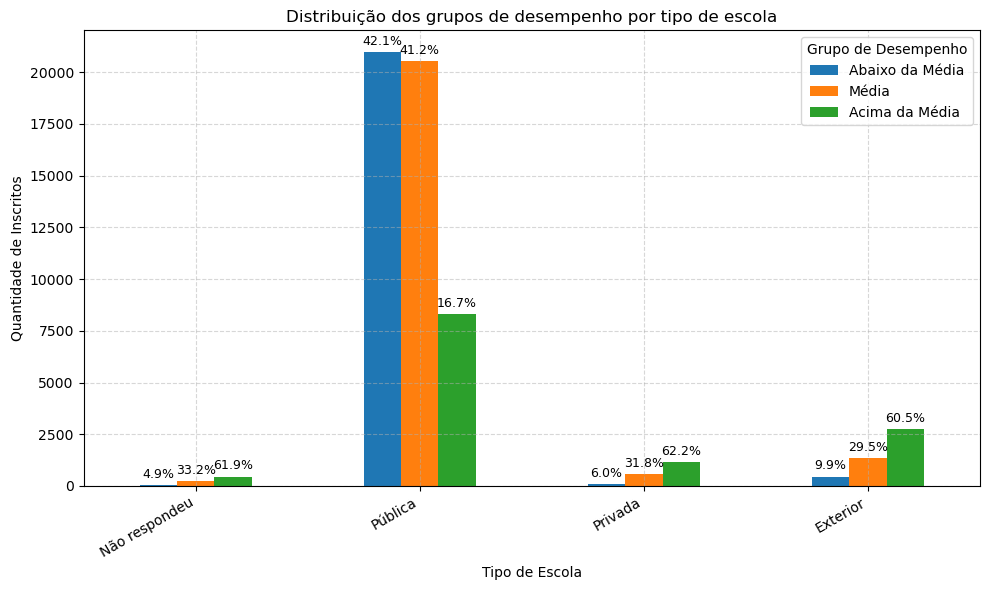

In [48]:
cols = ["TP_ESCOLA", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
base = df_ifnmg[cols].dropna().copy()

# Define a ordem dos tipos de escola conforme os códigos
ordem_escola = [1, 2, 4, 3]  # ordem: Não respondeu, Pública, Privada, Exterior
base["TP_ESCOLA"] = pd.Categorical(base["TP_ESCOLA"], categories=ordem_escola, ordered=True)

# Cria base de notas
X = base[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].values

# --- Executa K-Means com k=3 ---
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X)

# Ordena clusters pela média dos centróides
centers = kmeans.cluster_centers_
centers_mean = centers.mean(axis=1)
ordem_por_media = np.argsort(centers_mean)

# Mapeia a ordem para rótulos
rank_map = {lab: rank for rank, lab in enumerate(ordem_por_media)}
nomes = ["Abaixo da Média", "Média", "Acima da Média"]

base["Cluster"] = pd.Categorical(
    [nomes[rank_map[l]] for l in cluster_labels],
    categories=nomes, ordered=True
)

# --- Contagem de participantes por tipo de escola e cluster ---
contagem = (
    base.groupby(["TP_ESCOLA", "Cluster"], observed=True)
        .size()
        .rename("Quantidade")
        .reset_index()
)

# Cria tabela formatada
tabela = (
    contagem.pivot_table(
        index="TP_ESCOLA", columns="Cluster", values="Quantidade",
        aggfunc="sum", observed=True
    )
    .reindex(index=ordem_escola, columns=nomes)
    .fillna(0)
    .astype(int)
)

# Substitui códigos por rótulos descritivos
mapa_escola = {
    1: "Não respondeu",
    2: "Pública",
    3: "Exterior",
    4: "Privada"
}
tabela.index = [mapa_escola.get(i, i) for i in tabela.index]

# --- Calcula % por tipo de escola ---
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# --- Gráfico ---
ax = tabela.plot(kind="bar", figsize=(10, 6))
ax.set_title("Distribuição dos grupos de desempenho por tipo de escola")
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=30, ha="right")

# Exibe porcentagens sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Entre os participantes provenientes de escolas públicas, observa-se a maior concentração geral de inscritos em todos os grupos de desempenho, refletindo o volume expressivo desse segmento no total da amostra. Nesse grupo, 42,1% dos estudantes estão Abaixo da Média, 41,2% na Média e 16,7% Acima da Média, indicando que, embora exista um número considerável de bons desempenhos, a maioria ainda se concentra nos níveis médios e inferiores.

Já entre os alunos de escolas privadas, a distribuição revela um padrão distinto: apenas 6,0% estão Abaixo da Média, enquanto 31,8% encontram-se na Média e a maior parcela, 62,2%, está Acima da Média. Esse cenário demonstra um desempenho significativamente superior em comparação às escolas públicas.

Os participantes de escolas no exterior também apresentam resultados positivos, com 60,5% Acima da Média e apenas 9,9% Abaixo da Média, o que sugere um perfil de alto desempenho acadêmico. Já os que não responderam ao tipo de escola mostram uma distribuição mais equilibrada, mas com predominância de alunos Acima da Média (61,9%), embora representem um grupo pequeno.

Em síntese, o gráfico evidencia que o tipo de escola está fortemente relacionado ao desempenho dos participantes: enquanto as escolas privadas e do exterior concentram a maioria dos alunos com desempenho acima da média, as escolas públicas reúnem a maior quantidade de inscritos, mas com predominância nos níveis médios e abaixo da média.

### **Quantidade de inscritos por grupo para cada gênero**


Tabela (Sexo × Cluster) – numérica:
Cluster    Baixo  Médio   Alto  Total
Feminino   13439  14529   6555  34523
Masculino   7057   8819   6547  22423
Total      20496  23348  13102  56946


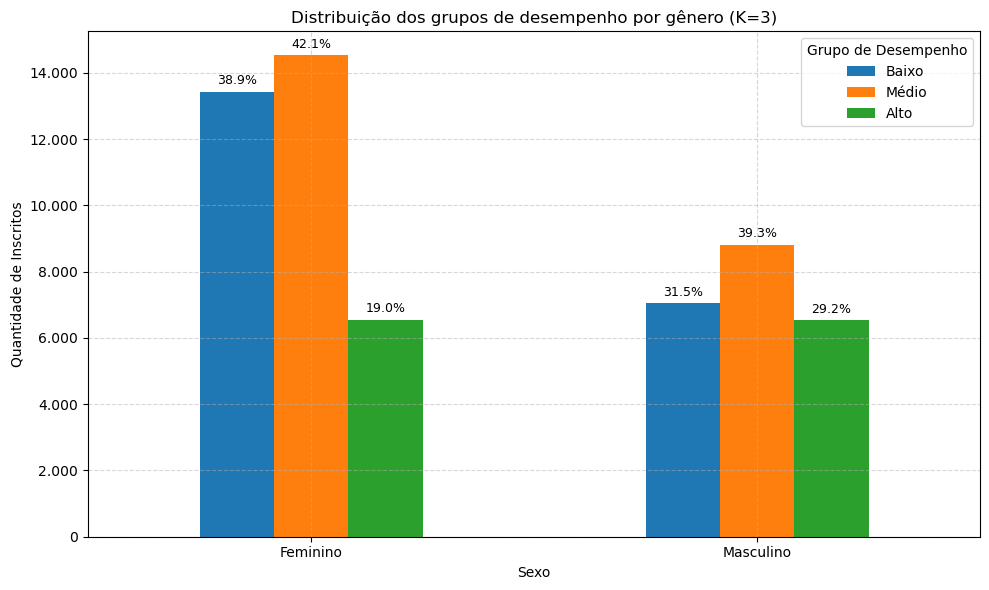

In [49]:
colunas_notas = ["TP_SEXO", "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_ifnmg[colunas_notas].dropna().copy()

# Criação dos clusters (K=3)
if "Cluster" not in notas.columns:
    X = notas[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]].values
    Xz = StandardScaler().fit_transform(X)
    
    km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    order = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {0: "Baixo", 1: "Médio", 2: "Alto"}
    
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# Contagem por sexo e cluster
contagem_sexo = (
    notas.groupby(["TP_SEXO", "Cluster"], observed=True)
         .size()
         .reset_index(name="Quantidade")
)

ordem_clusters = ["Baixo", "Médio", "Alto"]

tabela = (
    contagem_sexo.pivot_table(
        index="TP_SEXO", columns="Cluster",
        values="Quantidade", aggfunc="sum", observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)

# Ajusta rótulos de sexo
def rotulo_sexo(v):
    return {
        0: "Feminino", 1: "Masculino",
        "0": "Feminino", "1": "Masculino",
        "F": "Feminino", "M": "Masculino"
    }.get(v, str(v))

tabela.index = [rotulo_sexo(i) for i in tabela.index]

# Adiciona totais
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela (Sexo × Cluster) – numérica:")
print(tabela_tot)

# Percentuais por linha
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# Gráfico de barras
ax = tabela.plot(kind="bar", figsize=(10, 6))
ax.set_title("Distribuição dos grupos de desempenho por gênero (K=3)")
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.set_xticklabels(tabela.index, rotation=0)

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))
ax.grid(True, linestyle="--", alpha=0.5)

# Percentuais nas barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Entre as estudantes do gênero feminino, observa-se uma maior concentração nos grupos Baixo (38,9%) e Médio (42,1%), enquanto apenas 19,0% atingem o grupo de Alto desempenho.

Já entre os estudantes do gênero masculino, a proporção no grupo de Alto desempenho é mais elevada (29,2%), acompanhada de 31,5% no grupo Baixo e 39,3% no grupo Médio.

Esses resultados indicam que, embora as mulheres representem maior número total de participantes, os homens concentram maior proporção nos níveis mais altos de desempenho.
Por outro lado, o percentual feminino nos grupos Baixo e Médio é mais expressivo, sugerindo uma distribuição menos favorável quanto ao rendimento geral.

Ainda assim, a diferença entre os grupos Médio e Baixo é relativamente pequena, indicando que o desempenho de ambos os gêneros se concentra predominantemente no nível intermediário.

### **Quantidade de inscritos por grupo para cada cor/raça**


Tabela Raça × Cluster (numérica):
Cluster        Baixo  Médio   Alto  Total
Não declarado    275    314    241    830
Branca          3623   5380   4599  13602
Preta           3108   3316   1248   7672
Parda          12811  13718   6773  33302
Amarela          510    515    223   1248
Indígena         169    105     18    292
Total          20496  23348  13102  56946


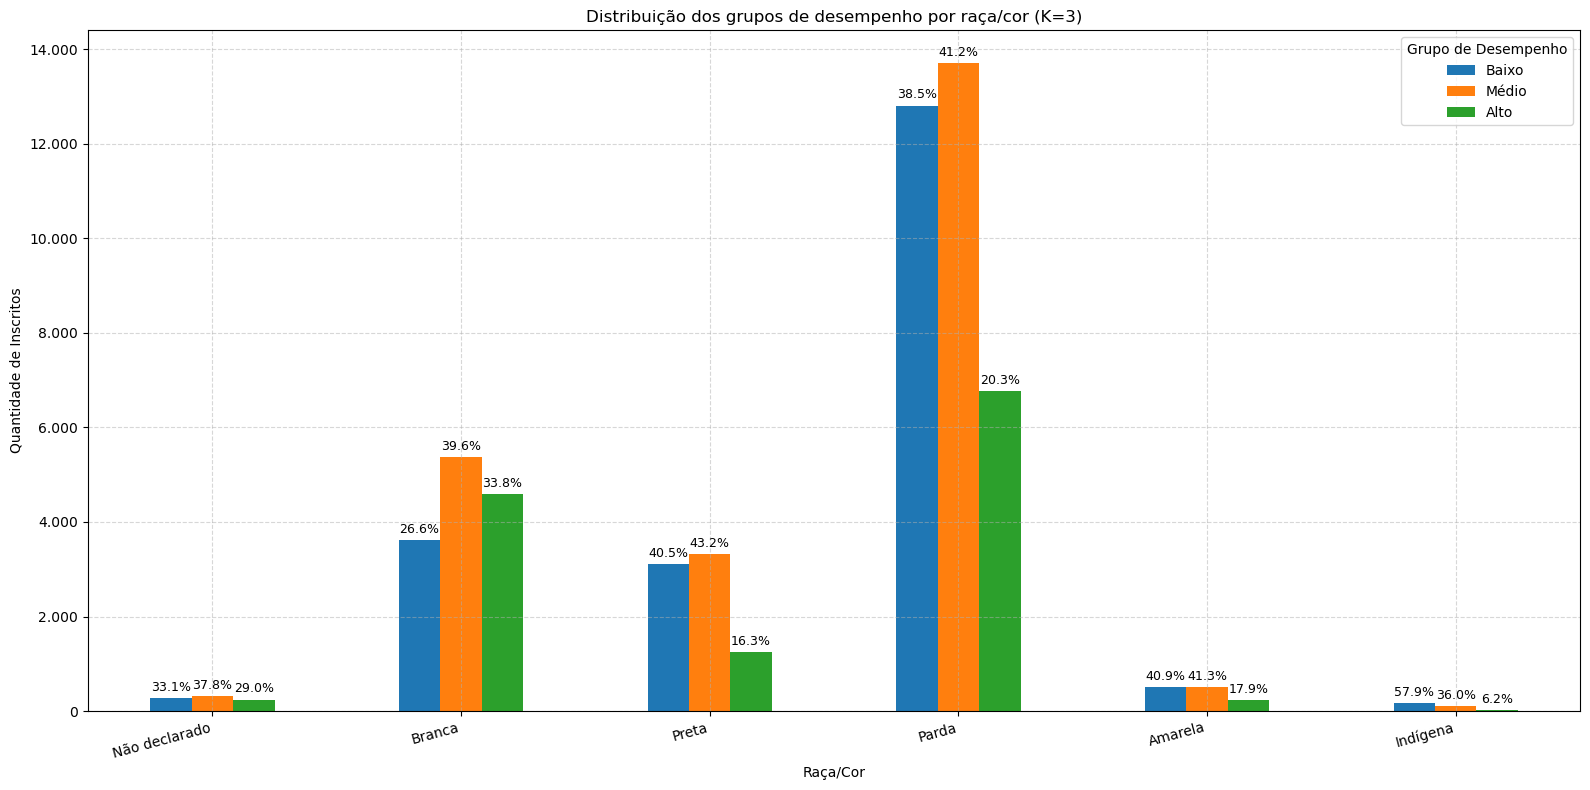

In [50]:
base = df_ifnmg.copy() if 'df_ifnmg' in globals() else df_final.copy()

if "TP_COR_RACA" not in base.columns:
    dummy_cols = [c for c in base.columns if c.startswith("COR_RACA_")]
    if not dummy_cols:
        raise ValueError("Não encontrei TP_COR_RACA nem colunas COR_RACA_* na base.")
    base["TP_COR_RACA"] = (
        base[dummy_cols]
        .idxmax(axis=1)
        .str.replace("COR_RACA_", "", regex=False)
        .astype(int)
    )

# --- Seleção das notas e clusterização ---
cols_notas = ["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]
notas = base[["TP_COR_RACA"] + cols_notas].dropna(subset=cols_notas).copy()

if "Cluster" not in notas.columns:
    Xz = StandardScaler().fit_transform(notas[cols_notas].values)
    km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    order = centers.mean(axis=1).argsort()  # pior → melhor
    old2rank = {old: r for r, old in enumerate(order)}
    rank2name = {0:"Baixo", 1:"Médio", 2:"Alto"}
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# --- Contagem e tabela ---
contagem_raca = (
    notas.groupby(["TP_COR_RACA","Cluster"])
         .size()
         .reset_index(name="Quantidade")
)

ordem_raca = [0,1,2,3,4,5]
ordem_clusters = ["Baixo","Médio","Alto"]

tabela = (
    contagem_raca.pivot(index="TP_COR_RACA", columns="Cluster", values="Quantidade")
                 .reindex(index=[r for r in ordem_raca if r in contagem_raca["TP_COR_RACA"].unique()],
                          columns=ordem_clusters)
                 .fillna(0).astype(int)
)

# --- Rótulos de raça/cor ---
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena",
}
tabela.index = [mapa_raca[i] for i in tabela.index]

# --- Totais ---
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)
print("\nTabela Raça × Cluster (numérica):")
print(tabela_tot)

# --- Percentuais e gráfico ---
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
tabela.plot(kind="bar", ax=ax)

ax.set_title("Distribuição dos grupos de desempenho por raça/cor (K=3)")
ax.set_xlabel("Raça/Cor")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")
ax.legend(title="Grupo de Desempenho")

ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))
ax.grid(True, linestyle="--", alpha=0.5)

# Rótulos de % em cada barra
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


Os grupos preto e pardo apresentam a maior concentração de participantes nos níveis Baixo e Médio de desempenho.
Entre os estudantes pardos, que representam a maior parcela dos inscritos, quase 80% se concentram nos dois níveis inferiores — 38,5% no grupo Baixo e 41,2% no grupo Médio —, enquanto apenas 20,3% alcançam o grupo Alto.

Um padrão semelhante é observado entre os pretos, com 40,5% no grupo Baixo e 43,2% no grupo Médio. Apenas 16,3% estão entre os desempenhos mais altos, o que reforça a persistência de desigualdades raciais no rendimento escolar.

Os estudantes brancos apresentam uma distribuição mais equilibrada: 26,6% no grupo Baixo, 39,6% no Médio e 33,8% no Alto.
Essa proporção é visivelmente superior à dos grupos preto e pardo no desempenho mais elevado, indicando melhor desempenho médio entre os estudantes brancos.

Já entre os amarelos, observa-se 41,3% no grupo Médio, 40,9% no Baixo e 17,9% no Alto — um padrão semelhante ao dos grupos mais vulneráveis, sugerindo que o tamanho reduzido da amostra pode influenciar a distribuição observada.

O grupo indígena apresenta o desempenho mais concentrado nos níveis baixos, com 57,9% no grupo Baixo e apenas 6,2% no Alto, revelando um quadro de maior desigualdade e vulnerabilidade educacional.
Já os que não declararam raça/cor mostram distribuição mais equilibrada, com leve predominância no grupo Médio (37,8%) e desempenho Alto em 29% dos casos.

### **Quantidade de inscritos por grupo para cada faixa de renda mensal**

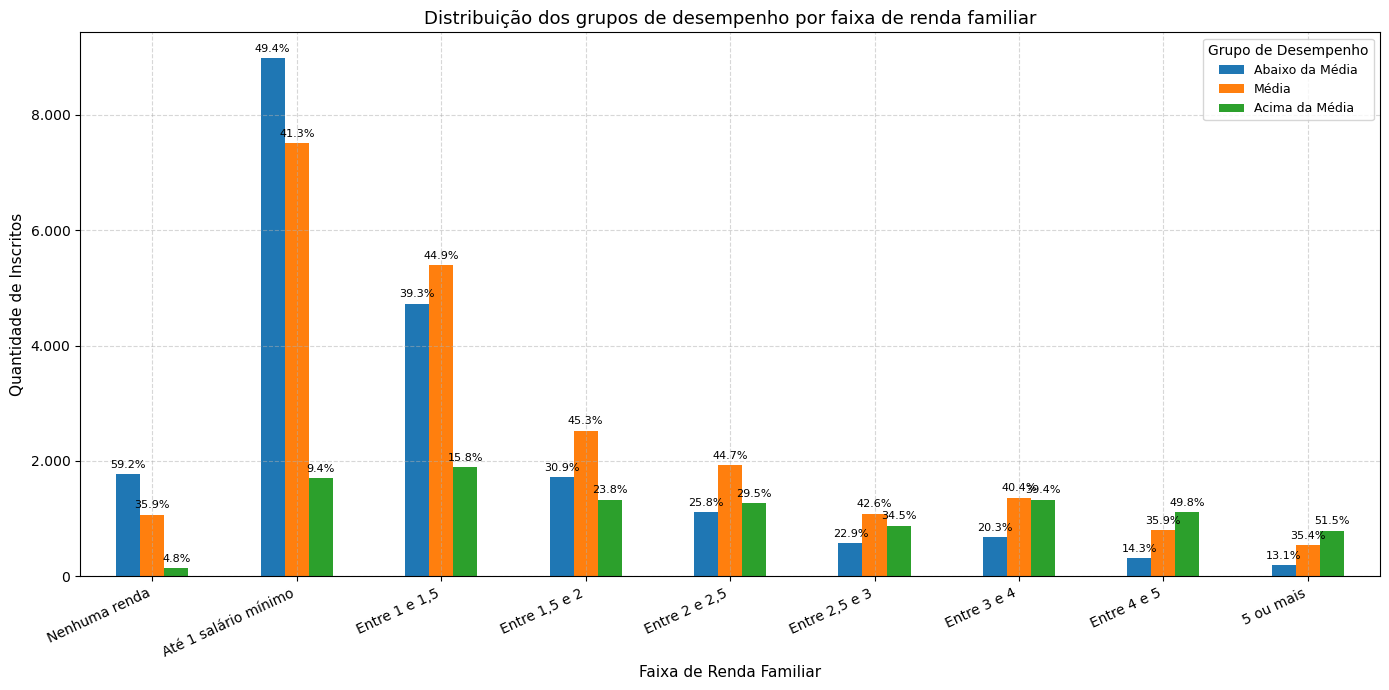

In [51]:
base = df_ifnmg.copy()

# Garante que exista a coluna RENDA_MENSAL
if "RENDA_MENSAL" not in base.columns:
    renda_dummies = [c for c in base.columns if c.startswith("RENDA_MENSAL_")]
    if not renda_dummies:
        raise ValueError("Não encontrei coluna 'RENDA_MENSAL' nem dummies 'RENDA_MENSAL_*'.")
    base["RENDA_MENSAL"] = (
        base[renda_dummies].idxmax(axis=1)
                           .str.replace("RENDA_MENSAL_", "", regex=False)
    )

# Seleciona notas e renda
cols_notas = ["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]
notas = base[["RENDA_MENSAL"] + cols_notas].dropna(subset=cols_notas).copy()

# Clusters pelas notas (k=3)
if "Cluster" not in notas.columns:
    Xz = StandardScaler().fit_transform(notas[cols_notas].values)
    km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(Xz)
    centers = km.cluster_centers_
    ordem = centers.mean(axis=1).argsort()  # pior -> melhor
    old2rank = {old: r for r, old in enumerate(ordem)}
    rank2name = {0:"Abaixo da Média", 1:"Média", 2:"Acima da Média"}
    notas["Cluster"] = [rank2name[old2rank[l]] for l in km.labels_]

# 🔹 Mapeia letras para faixas reais de renda
mapa_renda = {
    "A": "Nenhuma renda",
    "B": "Até 1 salário mínimo",
    "C": "Entre 1 e 1,5",
    "D": "Entre 1,5 e 2",
    "E": "Entre 2 e 2,5",
    "F": "Entre 2,5 e 3",
    "G": "Entre 3 e 4",
    "H": "Entre 4 e 5",
    "I": "5 ou mais"
}

# Filtra e substitui letras por descrições
notas = notas[notas["RENDA_MENSAL"].isin(mapa_renda.keys())].copy()
notas["Faixa_Renda"] = notas["RENDA_MENSAL"].map(mapa_renda)

# Agrupa e calcula contagem
contagem_renda = (
    notas.groupby(["Faixa_Renda","Cluster"])
         .size()
         .reset_index(name="Quantidade")
)

ordem_clusters = ["Abaixo da Média","Média","Acima da Média"]
ordem_renda = [
    "Nenhuma renda",
    "Até 1 salário mínimo",
    "Entre 1 e 1,5",
    "Entre 1,5 e 2",
    "Entre 2 e 2,5",
    "Entre 2,5 e 3",
    "Entre 3 e 4",
    "Entre 4 e 5",
    "5 ou mais"
]

# Cria tabela formatada
tabela = (
    contagem_renda.pivot(index="Faixa_Renda", columns="Cluster", values="Quantidade")
                  .reindex(index=ordem_renda, columns=ordem_clusters)
                  .fillna(0).astype(int)
)

# Calcula percentuais
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100

# 🔹 Gráfico
fig, ax = plt.subplots(figsize=(14,7))
tabela.plot(kind="bar", ax=ax)

ax.set_title("Distribuição dos grupos de desempenho por faixa de renda familiar", fontsize=13)
ax.set_xlabel("Faixa de Renda Familiar", fontsize=11)
ax.set_ylabel("Quantidade de Inscritos", fontsize=11)
ax.set_xticklabels(tabela.index, rotation=25, ha="right")
ax.legend(title="Grupo de Desempenho", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

# Formata eixo y com separador de milhar
from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))

# Adiciona rótulos de percentual em cada barra
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()


Entre os estudantes com nenhuma renda ou até 1 salário mínimo, observa-se forte concentração nos grupos de desempenho Abaixo da Média.
Nessas faixas, mais de 60% dos inscritos estão nesse grupo, enquanto apenas cerca de 10% a 15% alcançam o nível Acima da Média, evidenciando desigualdades expressivas associadas à renda.

Na faixa de até 1,5 salário mínimo, nota-se uma leve melhora: a proporção de alunos Abaixo da Média diminui, enquanto os grupos Média e Acima da Média ganham espaço, indicando um início de ascensão no desempenho conforme aumenta a renda familiar.


Nas faixas intermediárias, o desempenho se distribui de forma mais equilibrada entre os três grupos.
Entre os estudantes com renda de 2 a 2,5 salários mínimos, cerca de 45% estão no grupo Média, 30% no Acima da Média e 25% no Abaixo da Média, mostrando uma melhora significativa em relação às faixas de menor renda.

Esse comportamento sugere que o aumento da renda familiar contribui para uma melhora gradual no desempenho escolar, possivelmente pela ampliação do acesso a recursos educacionais, ambiente de estudo mais adequado e menor vulnerabilidade socioeconômica.


A partir de 3 salários mínimos, o cenário se inverte: o grupo Acima da Média passa a ser predominante.
Entre os alunos com renda de 3 a 4 salários, cerca de 50% estão nesse grupo, e nas faixas acima de 4 salários mínimos, essa proporção ultrapassa 60%, enquanto o grupo Abaixo da Média cai para menos de 20% dos participantes.

Esses resultados evidenciam uma relação direta entre renda e desempenho acadêmico.
Quanto maior a renda familiar, menor a proporção de estudantes nos grupos de baixo desempenho e maior a concentração nos de desempenho elevado.

## **TESTE**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, Birch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# ====== Pré-processamento ======
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()
notas["MEDIA_GERAL"] = notas.mean(axis=1)

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

# ====== Número de clusters ======
k = 4

# ====== Modelo 1: K-Means ======
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_norm)

# ====== Modelo 2: Birch ======
birch = Birch(n_clusters=k)
labels_birch = birch.fit_predict(df_norm)

# ====== Métrica de estabilidade ======
ari = adjusted_rand_score(labels_kmeans, labels_birch)
print(f"Índice Rand Ajustado (ARI) entre K-Means e Birch: {ari:.3f}")

# ====== Visualização ======
plt.figure(figsize=(6, 4))
plt.bar(["Estabilidade (ARI)"], [ari], color="#a3c585")
plt.ylim(0, 1)
plt.title("Estabilidade entre K-Means e Birch")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# ====== Pré-processamento ======
df_notas = df_ifnmg.copy()

colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
notas = df_notas[colunas_notas].dropna()
notas["MEDIA_GERAL"] = notas.mean(axis=1)

scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(notas), columns=notas.columns)

# ====== Número de clusters ======
k = 4

# ====== Modelo 1: K-Means tradicional ======
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(df_norm)

# ====== Modelo 2: MiniBatch K-Means ======
mini_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)
labels_mini = mini_kmeans.fit_predict(df_norm)

# ====== Métrica de estabilidade ======
ari = adjusted_rand_score(labels_kmeans, labels_mini)
print(f"Índice Rand Ajustado (ARI) entre K-Means e MiniBatch K-Means: {ari:.3f}")

# ====== Visualização ======
plt.figure(figsize=(6, 4))
plt.bar(["Estabilidade (ARI)"], [ari], color="#6fa8dc")
plt.ylim(0, 1)
plt.title("Estabilidade entre K-Means e MiniBatch K-Means")
plt.ylabel("Adjusted Rand Index (ARI)")
plt.show()
